In [73]:
# Set working directory. Setting it to the Raw Data folder so I can pull in the datasets I need. 
getwd()
setwd('/home/user/capstone/irs_eds_capstone/data/raw_data/')
getwd()

[1] "/home/user/capstone/irs_eds_capstone/data/raw_data"

[1] "/home/user/capstone/irs_eds_capstone/data/raw_data"

In [74]:
# Load in libraries for data cleaning and visualization
library(dplyr)
library(car)
library(GGally)
library(ggplot2)
library(stringr)
library(tidyverse)
library(corrplot)
library(lubridate)

In [75]:
# Read in SNAP CSV file. This is the raw file that has total snap recipients from 2009-2019. This data was provided by the NYC Human Resources Administration (HRA), and found on the NYC Open Data website: 

# https://data.cityofnewyork.us/Social-Services/Total-SNAP-Recipients-Historical-/5c4s-jwtq/about_data

snap_data <- read.csv('Total_SNAP_Recipients_(Historical)_20260128.csv', header = TRUE)

# Explore the data file
dim(snap_data)
names(snap_data)
glimpse(snap_data)
summary(snap_data)
str(snap_data)
head(snap_data)
tail(snap_data)

[1] 124   2

[1] "Month"                 "Total.SNAP.Recipients"

Rows: 124
Columns: 2
$ Month                 <chr> "Apr 2019", "Mar 2019", "Feb 2019", "Jan 2019", …
$ Total.SNAP.Recipients <chr> "1,550,397", "1,561,666", "1,564,537", "1,570,53…


    Month           Total.SNAP.Recipients
 Length:124         Length:124           
 Class :character   Class :character     
 Mode  :character   Mode  :character     

'data.frame':	124 obs. of  2 variables:
 $ Month                : chr  "Apr 2019" "Mar 2019" "Feb 2019" "Jan 2019" ...
 $ Total.SNAP.Recipients: chr  "1,550,397" "1,561,666" "1,564,537" "1,570,537" ...


,Month,Total.SNAP.Recipients
,<chr>,<chr>
1,Apr 2019,"1,550,397"
2,Mar 2019,"1,561,666"
3,Feb 2019,"1,564,537"
4,Jan 2019,"1,570,537"
5,Dec 2018,"1,571,790"
6,Nov 2018,"1,577,524"


,Month,Total.SNAP.Recipients
,<chr>,<chr>
119,Jun 2009,"1,502,368"
120,May 2009,"1,473,304"
121,Apr 2009,"1,444,403"
122,Mar 2009,"1,415,907"
123,Feb 2009,"1,390,204"
124,Jan 2009,"1,366,942"


In [76]:
# Change column name so it avoids any spaces or special characters
snap_data_clean <- rename(snap_data,
                          month = "Month",
                          total_SNAP_recipients = "Total.SNAP.Recipients")

names(snap_data_clean)

# Change dates so they are formatted better 
snap_data_clean$month <- my(snap_data_clean$month)

head(snap_data_clean)

# Remove commas from total_SNAP_recipients so it can be used as a numeric not a character
snap_data_clean <- snap_data_clean %>%
                        mutate(
                            total_SNAP_recipients = parse_number(total_SNAP_recipients))


glimpse(snap_data_clean)


[1] "month"                 "total_SNAP_recipients"

,month,total_SNAP_recipients
,<date>,<chr>
1,2019-04-01,"1,550,397"
2,2019-03-01,"1,561,666"
3,2019-02-01,"1,564,537"
4,2019-01-01,"1,570,537"
5,2018-12-01,"1,571,790"
6,2018-11-01,"1,577,524"


Rows: 124
Columns: 2
$ month                 <date> 2019-04-01, 2019-03-01, 2019-02-01, 2019-01-01,…
$ total_SNAP_recipients <dbl> 1550397, 1561666, 1564537, 1570537, 1571790, 157…


In [77]:
# Check for NAs
sum(is.na(snap_data_clean$month))
sum(is.na(snap_data_clean$total_SNAP_recipients))

length(snap_data_clean$month)
length(snap_data_clean$total_SNAP_recipients)

head(snap_data_clean$month, 10)
class(snap_data_clean$month)

head(snap_data_clean$total_SNAP_recipients, 10)
class(snap_data_clean$total_SNAP_recipients)

[1] 0

[1] 0

[1] 124

[1] 124

[1] "2019-04-01" "2019-03-01" "2019-02-01" "2019-01-01" "2018-12-01"
 [6] "2018-11-01" "2018-10-01" "2018-09-01" "2018-08-01" "2018-07-01"

[1] "Date"

[1] 1550397 1561666 1564537 1570537 1571790 1577524 1590812 1594530 1604622
[10] 1603658

[1] "numeric"

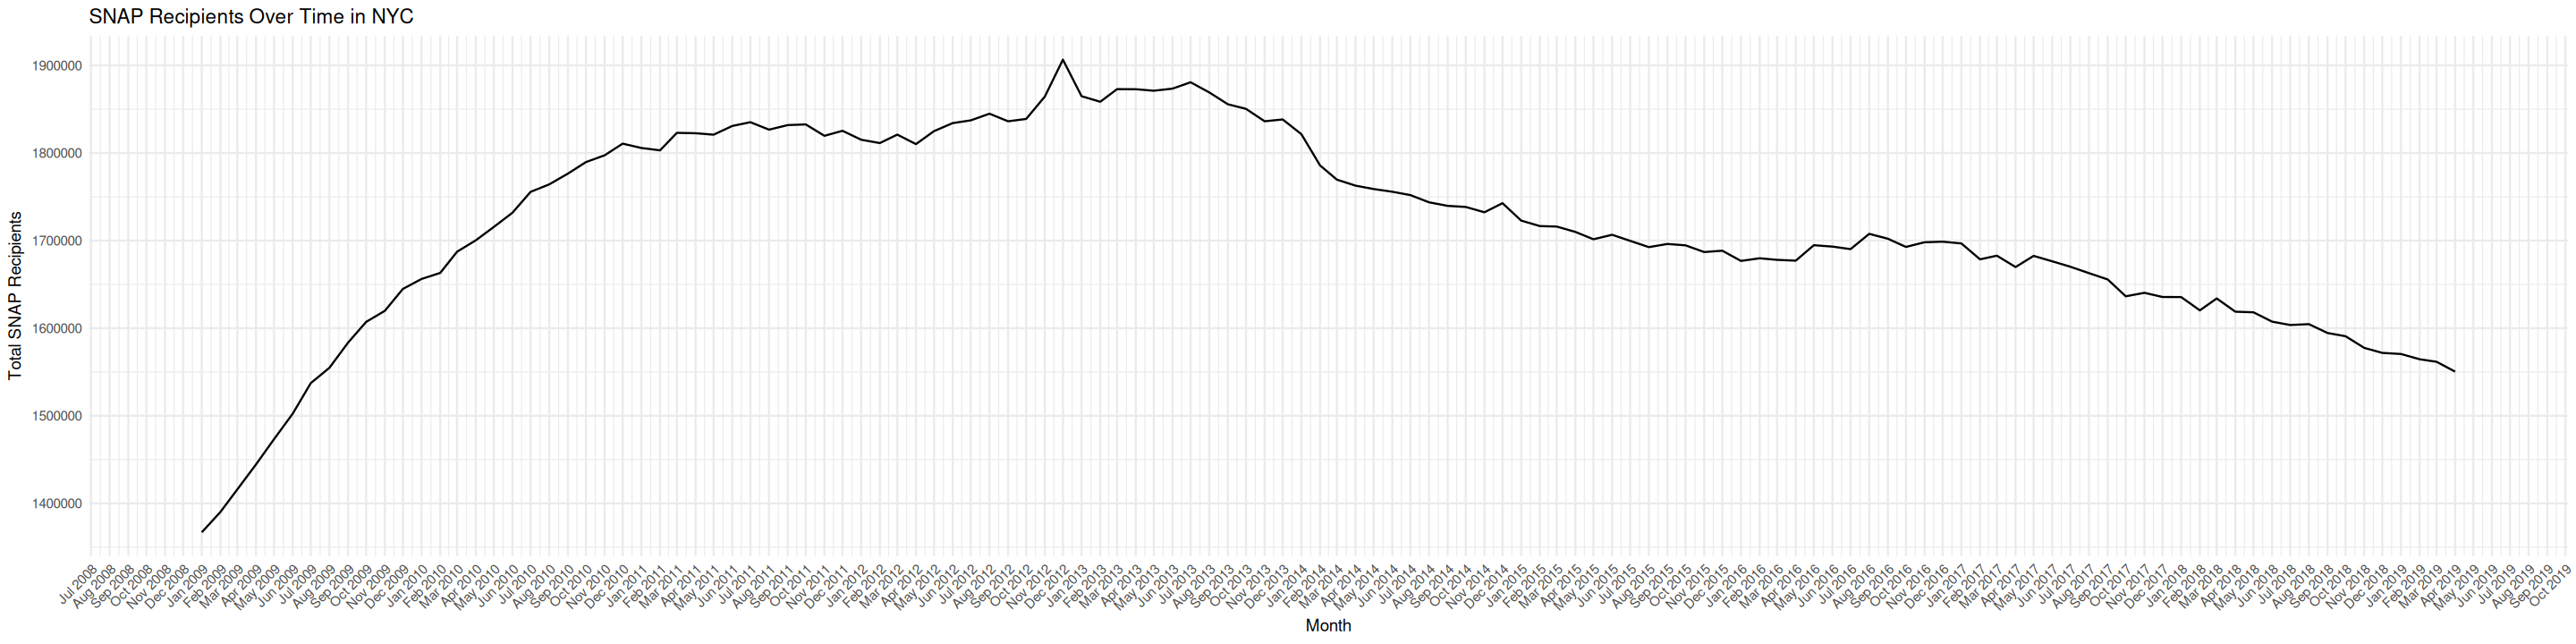

In [78]:

# Visualize the timeseries data
options(repr.plot.width=24, repr.plot.height=6)


snap_timeseries <- ggplot(snap_data_clean, aes(x=month, y=total_SNAP_recipients)) +
                        geom_line() +
                        labs(title = "SNAP Recipients Over Time in NYC",
                            x = "Month",
                            y = "Total SNAP Recipients") +
                        scale_x_date(date_breaks = "1 month", 
                                     date_labels = "%b %Y") +                        
                        theme_minimal() +
                        theme(axis.text.x = element_text(angle = 45, hjust = 1))
                           
snap_timeseries

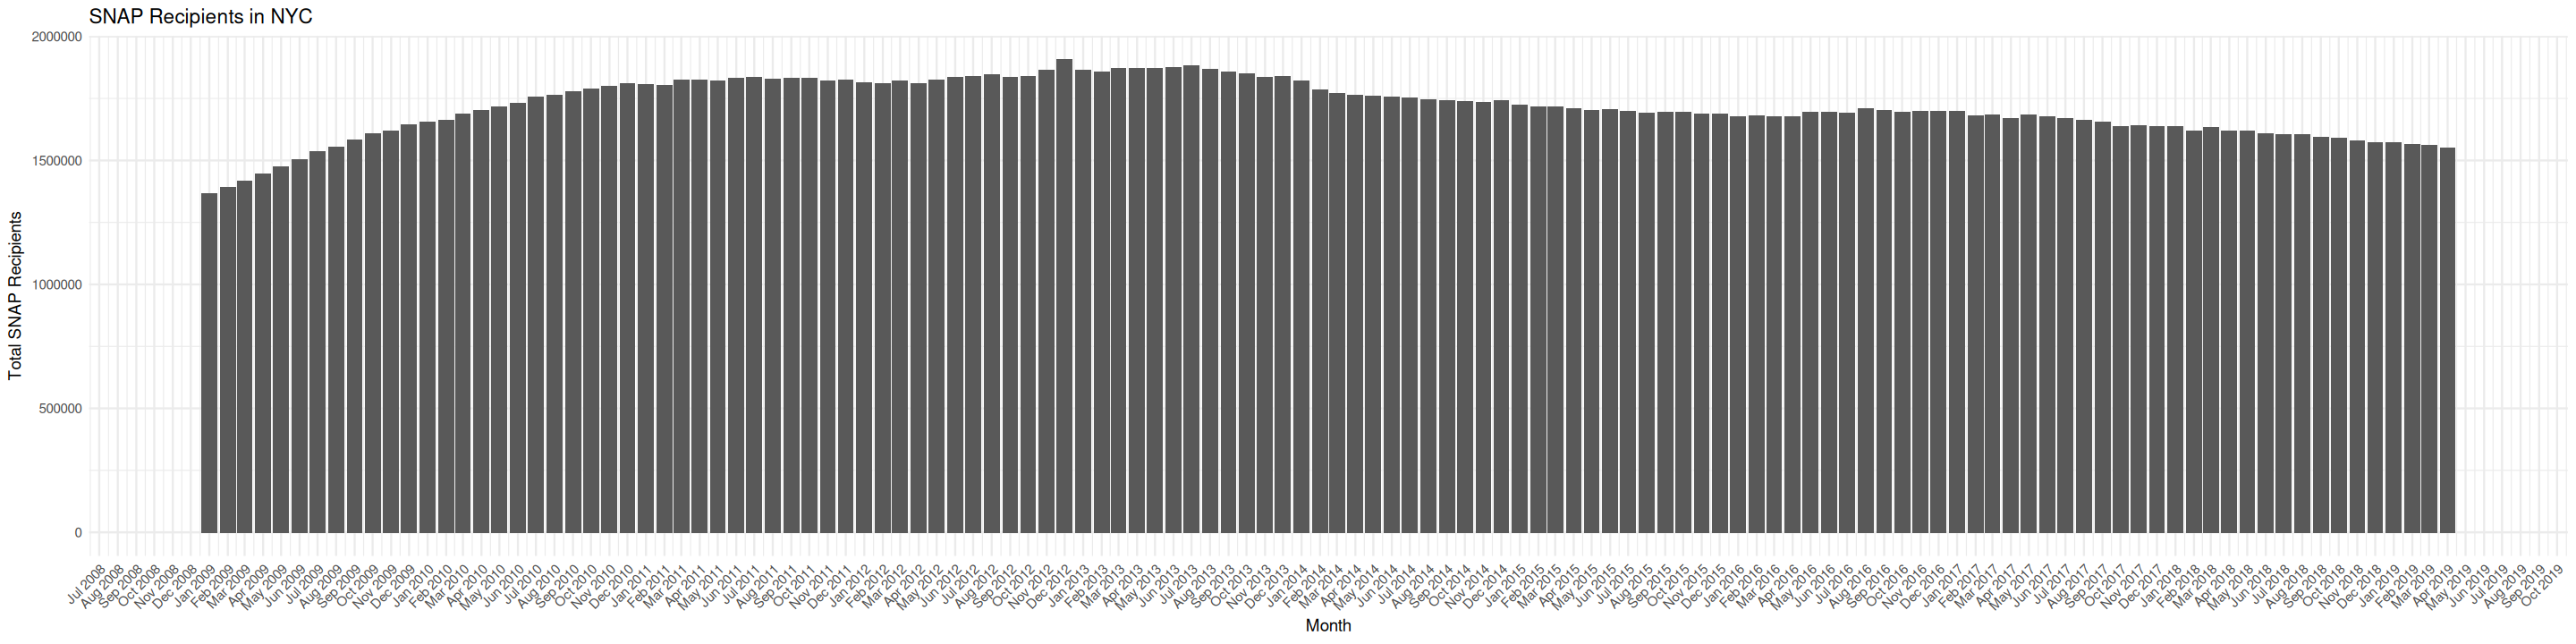

In [79]:
# plot snap bar chart
snap_bar <- ggplot(snap_data_clean, aes(x=month, y=total_SNAP_recipients)) +
                        geom_col() +
                        labs(title = "SNAP Recipients in NYC",
                            x = "Month",
                            y = "Total SNAP Recipients") +
                        scale_x_date(date_breaks = "1 month", 
                                     date_labels = "%b %Y") +                        
                        theme_minimal() +
                        theme(axis.text.x = element_text(angle = 45, hjust = 1))
                           
snap_bar

In [80]:
# Now let's start cleaning up our temp data. I got monthly temp data from the National Weather Service (https://www.weather.gov/okx/centralparkhistorical)

# the data I got was in pdf format, not CSV format, so I uploaded the PDF of historical temperatures measured in Central Park to Claud and Claud gave me a CSV file: central_park_temps.csv (https://www.weather.gov/media/okx/Climate/CentralPark/monthlyannualtemp.pdf)

# Read in csv file
monthly_temp <- read.csv('central_park_temps.csv', header = TRUE)

# Explore the data file
dim(monthly_temp)
names(monthly_temp)
glimpse(monthly_temp)
summary(monthly_temp)
str(monthly_temp)
head(monthly_temp)
tail(monthly_temp)

[1] 158  14

[1] "YEAR"   "JAN"    "FEB"    "MAR"    "APR"    "MAY"    "JUN"    "JUL"   
 [9] "AUG"    "SEP"    "OCT"    "NOV"    "DEC"    "ANNUAL"

Rows: 158
Columns: 14
$ YEAR   <int> 2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 201…
$ JAN    <dbl> NA, 31.2, 37.0, 43.5, 30.3, 34.8, 39.1, 32.5, 31.7, 38.0, 34.5,…
$ FEB    <dbl> NA, 35.0, 40.1, 41.1, 37.3, 34.2, 40.1, 36.2, 42.0, 41.6, 37.7,…
$ MAR    <dbl> NA, 46.9, 48.1, 44.6, 45.3, 45.8, 48.0, 41.7, 40.1, 39.2, 48.9,…
$ APR    <dbl> NA, 55.3, 55.6, 57.6, 52.8, 54.6, 50.4, 55.5, 49.5, 57.2, 53.3,…
$ MAY    <dbl> NA, 62.3, 65.0, 62.7, 64.0, 62.9, 60.3, 62.2, 66.9, 61.1, 62.8,…
$ JUN    <dbl> NA, 73.2, 75.1, 70.0, 71.4, 74.3, 73.7, 71.7, 71.7, 72.0, 72.3,…
$ JUL    <dbl> NA, 79.5, 79.6, 79.0, 79.5, 76.0, 80.0, 79.6, 77.6, 76.8, 78.7,…
$ AUG    <dbl> NA, 73.8, 75.1, 75.0, 79.3, 77.5, 76.9, 75.5, 78.1, 74.0, 79.2,…
$ SEP    <dbl> NA, 70.6, 68.8, 69.4, 69.5, 70.3, 68.8, 70.4, 70.7, 70.5, 71.8,…
$ OCT    <dbl> NA, 58.5, 60.9, 60.5, 56.9, 62.0, 57.9, 59.9, 57.7, 64.1, 58.8,…
$ NOV    <dbl> NA, 47.2, 51.4, 46.7, 50.9, 46.2, 53.0, 43.9, 44.4, 46.6, 49.8,…
$ DEC    <dbl> NA,

      YEAR           JAN             FEB             MAR             APR       
 Min.   :1869   Min.   :21.70   Min.   :19.90   Min.   :30.00   Min.   :41.10  
 1st Qu.:1908   1st Qu.:29.10   1st Qu.:30.00   1st Qu.:37.60   1st Qu.:49.10  
 Median :1948   Median :32.00   Median :33.20   Median :40.40   Median :51.20  
 Mean   :1948   Mean   :32.15   Mean   :33.05   Mean   :40.61   Mean   :51.33  
 3rd Qu.:1987   3rd Qu.:35.30   3rd Qu.:36.20   3rd Qu.:43.40   3rd Qu.:53.70  
 Max.   :2026   Max.   :43.50   Max.   :42.00   Max.   :51.10   Max.   :57.90  
                NA's   :1       NA's   :1       NA's   :1       NA's   :1      
      MAY             JUN             JUL             AUG             SEP      
 Min.   :54.30   Min.   :64.20   Min.   :70.70   Min.   :68.50   Min.   :60.8  
 1st Qu.:60.10   1st Qu.:69.80   1st Qu.:74.80   1st Qu.:73.20   1st Qu.:66.6  
 Median :61.90   Median :71.20   Median :76.20   Median :74.60   Median :67.9  
 Mean   :61.99   Mean   :71.09   Mean   

'data.frame':	158 obs. of  14 variables:
 $ YEAR  : int  2026 2025 2024 2023 2022 2021 2020 2019 2018 2017 ...
 $ JAN   : num  NA 31.2 37 43.5 30.3 34.8 39.1 32.5 31.7 38 ...
 $ FEB   : num  NA 35 40.1 41.1 37.3 34.2 40.1 36.2 42 41.6 ...
 $ MAR   : num  NA 46.9 48.1 44.6 45.3 45.8 48 41.7 40.1 39.2 ...
 $ APR   : num  NA 55.3 55.6 57.6 52.8 54.6 50.4 55.5 49.5 57.2 ...
 $ MAY   : num  NA 62.3 65 62.7 64 62.9 60.3 62.2 66.9 61.1 ...
 $ JUN   : num  NA 73.2 75.1 70 71.4 74.3 73.7 71.7 71.7 72 ...
 $ JUL   : num  NA 79.5 79.6 79 79.5 76 80 79.6 77.6 76.8 ...
 $ AUG   : num  NA 73.8 75.1 75 79.3 77.5 76.9 75.5 78.1 74 ...
 $ SEP   : num  NA 70.6 68.8 69.4 69.5 70.3 68.8 70.4 70.7 70.5 ...
 $ OCT   : num  NA 58.5 60.9 60.5 56.9 62 57.9 59.9 57.7 64.1 ...
 $ NOV   : num  NA 47.2 51.4 46.7 50.9 46.2 53 43.9 44.4 46.6 ...
 $ DEC   : num  NA 33.8 38.2 44.6 38.5 43.8 39.2 38.3 40.1 33.4 ...
 $ ANNUAL: num  NA 55.6 57.9 57.9 56.3 56.9 57.3 55.6 55.9 56.3 ...


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2026,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,2025,31.2,35.0,46.9,55.3,62.3,73.2,79.5,73.8,70.6,58.5,47.2,33.8,55.6
3,2024,37.0,40.1,48.1,55.6,65.0,75.1,79.6,75.1,68.8,60.9,51.4,38.2,57.9
4,2023,43.5,41.1,44.6,57.6,62.7,70.0,79.0,75.0,69.4,60.5,46.7,44.6,57.9
5,2022,30.3,37.3,45.3,52.8,64.0,71.4,79.5,79.3,69.5,56.9,50.9,38.5,56.3
6,2021,34.8,34.2,45.8,54.6,62.9,74.3,76.0,77.5,70.3,62.0,46.2,43.8,56.9


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
153,1874,34.2,31.3,37.1,41.1,58.8,70.1,73.9,70.3,67.0,55.1,43.4,33.8,51.3
154,1873,28.6,29.5,35.7,46.7,58.8,70.3,75.4,72.0,65.4,55.8,37.0,36.5,51.0
155,1872,28.8,29.9,30.5,49.4,61.5,71.2,77.5,75.6,66.4,53.2,41.0,26.7,51.0
156,1871,28.3,30.2,44.2,52.0,60.4,68.2,72.3,73.6,60.8,55.6,38.8,29.2,51.1
157,1870,37.5,31.3,34.1,50.7,60.9,72.9,76.6,75.3,67.6,56.7,45.5,34.1,53.6
158,1869,35.1,34.5,34.8,49.2,57.7,69.3,72.8,71.8,65.6,50.9,40.3,34.7,51.4


In [81]:
# Get rid of irrelevant pieces of data: 2026 (which is filled with NAs becuase there is no monthly temp data for 2026) and annual. I also want to only keep the years and months that match up with the years and months I have in my SNAP dataset)
head(snap_data_clean) # 2019-04-01 is the most recent datapoint
tail(snap_data_clean) # 2009-01-01 is the earliest datapoint


# filter rows from monthly temp dataset
monthly_temp_clean <- monthly_temp %>%
    filter(YEAR >= 2009 & YEAR <= 2018)%>%
    select(YEAR:DEC)

head(monthly_temp_clean)
tail(monthly_temp_clean)

# pivot long so the structure matches snap dataeset
monthly_temp_long <- monthly_temp_clean %>%
                        pivot_longer(
                            cols = JAN:DEC,
                            names_to = "month",
                            values_to = "temperatureF")

head(monthly_temp_long)
tail(monthly_temp_long)

,month,total_SNAP_recipients
,<date>,<dbl>
1,2019-04-01,1550397
2,2019-03-01,1561666
3,2019-02-01,1564537
4,2019-01-01,1570537
5,2018-12-01,1571790
6,2018-11-01,1577524


,month,total_SNAP_recipients
,<date>,<dbl>
119,2009-06-01,1502368
120,2009-05-01,1473304
121,2009-04-01,1444403
122,2009-03-01,1415907
123,2009-02-01,1390204
124,2009-01-01,1366942


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018,31.7,42.0,40.1,49.5,66.9,71.7,77.6,78.1,70.7,57.7,44.4,40.1
2,2017,38.0,41.6,39.2,57.2,61.1,72.0,76.8,74.0,70.5,64.1,46.6,33.4
3,2016,34.5,37.7,48.9,53.3,62.8,72.3,78.7,79.2,71.8,58.8,49.8,38.3
4,2015,29.9,23.9,38.1,54.3,68.5,71.2,78.8,79.0,74.5,58.0,52.8,50.8
5,2014,28.6,31.6,37.7,52.3,64.0,72.5,76.1,74.5,69.7,59.6,45.3,40.5
6,2013,35.1,33.9,40.1,53.0,62.8,72.7,79.8,74.6,67.9,60.2,45.3,38.5


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,2014,28.6,31.6,37.7,52.3,64.0,72.5,76.1,74.5,69.7,59.6,45.3,40.5
6,2013,35.1,33.9,40.1,53.0,62.8,72.7,79.8,74.6,67.9,60.2,45.3,38.5
7,2012,37.3,40.9,50.9,54.8,65.1,71.0,78.8,76.7,68.8,58.0,43.9,41.5
8,2011,29.7,36.0,42.3,54.3,64.5,72.3,80.2,75.3,70.0,57.1,51.9,43.3
9,2010,32.5,33.1,48.2,57.9,65.3,74.7,81.3,77.4,71.1,58.1,47.9,32.8
10,2009,27.9,36.7,42.4,54.5,62.5,67.5,72.7,75.7,66.3,55.0,51.2,35.9


YEAR,month,temperatureF
<int>,<chr>,<dbl>
2018,JAN,31.7
2018,FEB,42.0
2018,MAR,40.1
2018,APR,49.5
2018,MAY,66.9
2018,JUN,71.7


YEAR,month,temperatureF
<int>,<chr>,<dbl>
2009,JUL,72.7
2009,AUG,75.7
2009,SEP,66.3
2009,OCT,55.0
2009,NOV,51.2
2009,DEC,35.9


In [82]:
# Since we only have Jan, Feb, March, and April of 2019 in the SNAP dataset, let's just eliminate those four months so we have from Jan. 2009-Dec. 2018 
snap_data_clean <- snap_data_clean %>%
                        filter(month < "2019-01-01")

head(snap_data_clean) # Now, my Snap data goes from Jan. 2009 until Dec. 2018

# update the format of snap dates so it's just month and year. 
snap_data_clean <- snap_data_clean %>%
  mutate(month = format(month, "%b %Y"))

head(snap_data_clean)

,month,total_SNAP_recipients
,<date>,<dbl>
1,2018-12-01,1571790
2,2018-11-01,1577524
3,2018-10-01,1590812
4,2018-09-01,1594530
5,2018-08-01,1604622
6,2018-07-01,1603658


,month,total_SNAP_recipients
,<chr>,<dbl>
1,Dec 2018,1571790
2,Nov 2018,1577524
3,Oct 2018,1590812
4,Sep 2018,1594530
5,Aug 2018,1604622
6,Jul 2018,1603658


In [83]:
# Now update the month column in your temperature dataset so it matches
monthly_temp_long <- monthly_temp_long %>%
    mutate(month = my(paste(month, YEAR)))

head(monthly_temp_long)

YEAR,month,temperatureF
<int>,<date>,<dbl>
2018,2018-01-01,31.7
2018,2018-02-01,42.0
2018,2018-03-01,40.1
2018,2018-04-01,49.5
2018,2018-05-01,66.9
2018,2018-06-01,71.7


In [84]:
# Now convert dates to match the Month year format that we did for SNAP
# update the format of temp dates so it's just month and year. 
monthly_temp_long <- monthly_temp_long %>%
  mutate(month = format(month, "%b %Y"))

head(monthly_temp_long)
tail(monthly_temp_long)
     
# Now get rid of the YEAR column in Monthly Temp data
monthly_temp_long <- monthly_temp_long %>%
    select(month:temperatureF)

head(monthly_temp_long)

YEAR,month,temperatureF
<int>,<chr>,<dbl>
2018,Jan 2018,31.7
2018,Feb 2018,42.0
2018,Mar 2018,40.1
2018,Apr 2018,49.5
2018,May 2018,66.9
2018,Jun 2018,71.7


YEAR,month,temperatureF
<int>,<chr>,<dbl>
2009,Jul 2009,72.7
2009,Aug 2009,75.7
2009,Sep 2009,66.3
2009,Oct 2009,55.0
2009,Nov 2009,51.2
2009,Dec 2009,35.9


month,temperatureF
<chr>,<dbl>
Jan 2018,31.7
Feb 2018,42.0
Mar 2018,40.1
Apr 2018,49.5
May 2018,66.9
Jun 2018,71.7


In [85]:
# Now, check both datasets:
head(snap_data_clean)
head(monthly_temp_long)

tail(snap_data_clean)
tail(monthly_temp_long)

length(snap_data_clean$month)
length(monthly_temp_long$month)


,month,total_SNAP_recipients
,<chr>,<dbl>
1,Dec 2018,1571790
2,Nov 2018,1577524
3,Oct 2018,1590812
4,Sep 2018,1594530
5,Aug 2018,1604622
6,Jul 2018,1603658


month,temperatureF
<chr>,<dbl>
Jan 2018,31.7
Feb 2018,42.0
Mar 2018,40.1
Apr 2018,49.5
May 2018,66.9
Jun 2018,71.7


,month,total_SNAP_recipients
,<chr>,<dbl>
115,Jun 2009,1502368
116,May 2009,1473304
117,Apr 2009,1444403
118,Mar 2009,1415907
119,Feb 2009,1390204
120,Jan 2009,1366942


month,temperatureF
<chr>,<dbl>
Jul 2009,72.7
Aug 2009,75.7
Sep 2009,66.3
Oct 2009,55.0
Nov 2009,51.2
Dec 2009,35.9


[1] 120

[1] 120

In [86]:
# Now that the datasets match in length and have the same timeframes, join the two

merged_snap_temp <- snap_data_clean %>%
    left_join(monthly_temp_long, by = 'month')

head(merged_snap_temp)

,month,total_SNAP_recipients,temperatureF
,<chr>,<dbl>,<dbl>
1,Dec 2018,1571790,40.1
2,Nov 2018,1577524,44.4
3,Oct 2018,1590812,57.7
4,Sep 2018,1594530,70.7
5,Aug 2018,1604622,78.1
6,Jul 2018,1603658,77.6


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


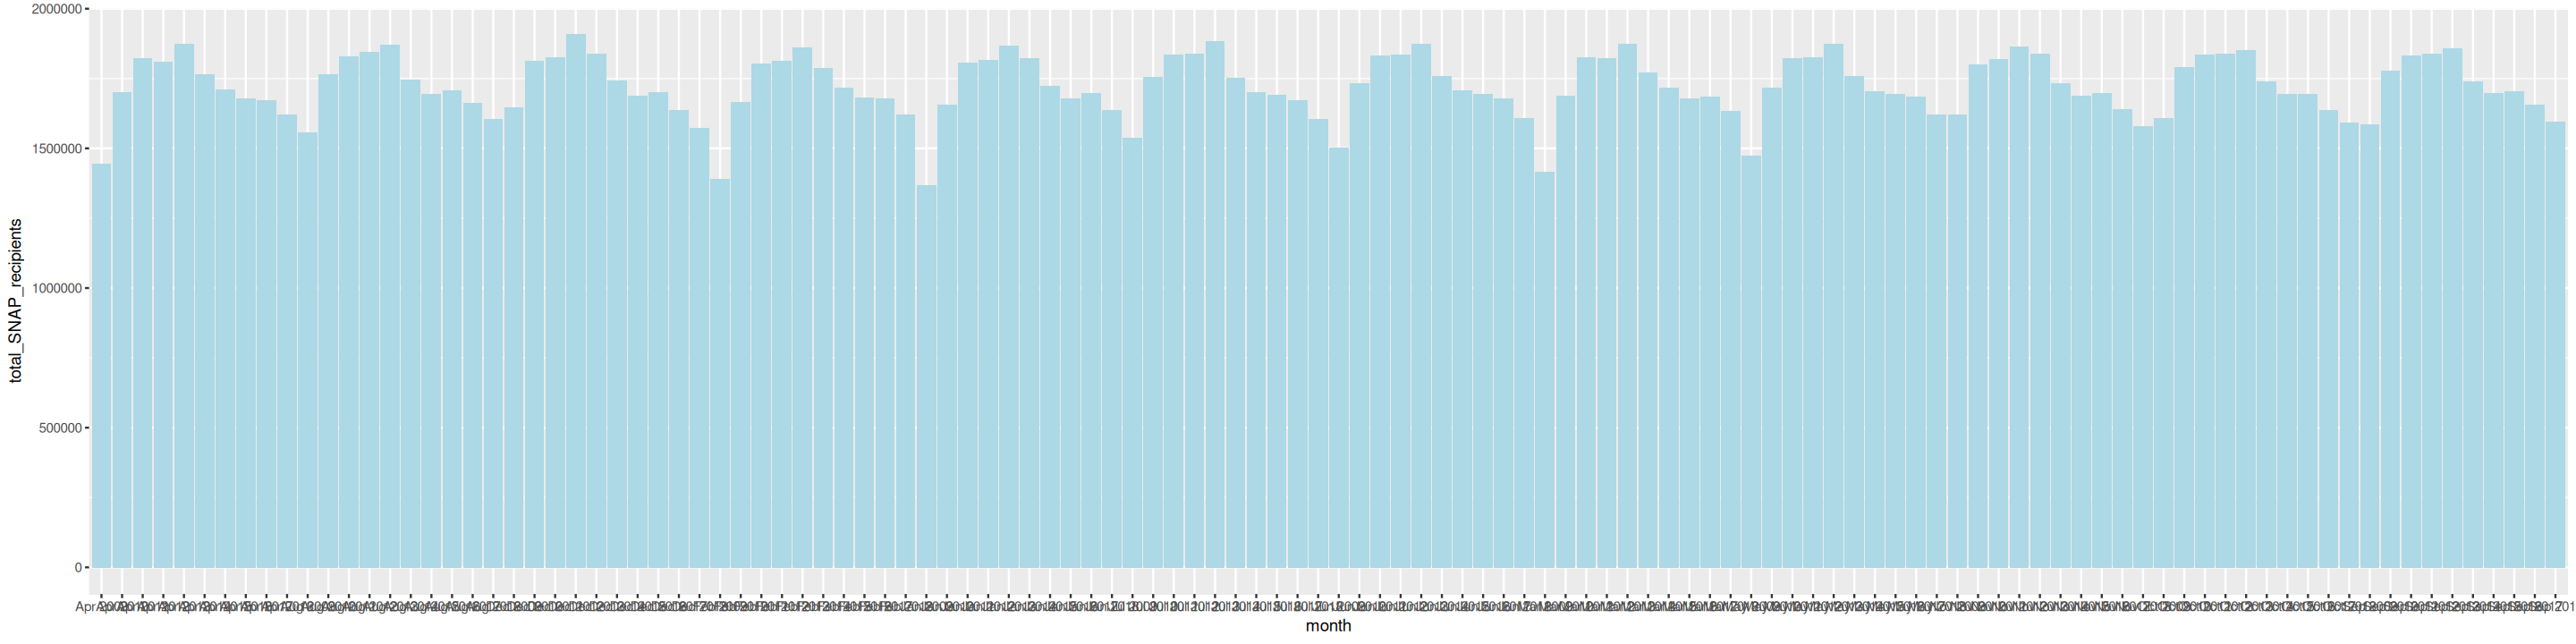

In [87]:
# try making a plot

ggplot(merged_snap_temp, aes(x = month)) +
    geom_col(aes(y = total_SNAP_recipients), fill = 'lightblue') +
    geom_line(aes(y = temperatureF))

# ggplot(merged_data, aes(x = month)) +
#   geom_col(aes(y = total_SNAP_recipients), fill = "lightblue", alpha = 0.7) +
#   geom_line(aes(y = Temperature * 10000, color = "Temperature"), size = 1) +
#   scale_y_continuous(
#     name = "SNAP Recipients",
#     sec.axis = sec_axis(~./10000, name = "Temperature (°F)")
#   ) +
#   labs(title = "SNAP Recipients and Temperature Over Time",
#        x = "Month",
#        color = "") +
#   scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
#   theme_minimal() +
#   theme(axis.text.x = element_text(angle = 45, hjust = 1),
#         legend.position = "top")

# timeseries_snap_temp <- ggplot(merged_snap_temp, aes(x=month)) + 
#     geom_col(aes(y = total_SNAP_recipients, color = "SNAP Recipients")) +
#     geom_line(aes(y = temperatureF, color = "TemperatureF")) +
#     labs(title = "SNAP Recipients and Temperature Over Time",
#          x = "Month",
#          y = "Value",
#          color = "Variable") +
#     scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
#     theme_minimal() +
#     theme(axis.text.x = element_text(angle = 45, hjust = 1))


# timeseries_snap_temp

`geom_smooth()` using formula = 'y ~ x'


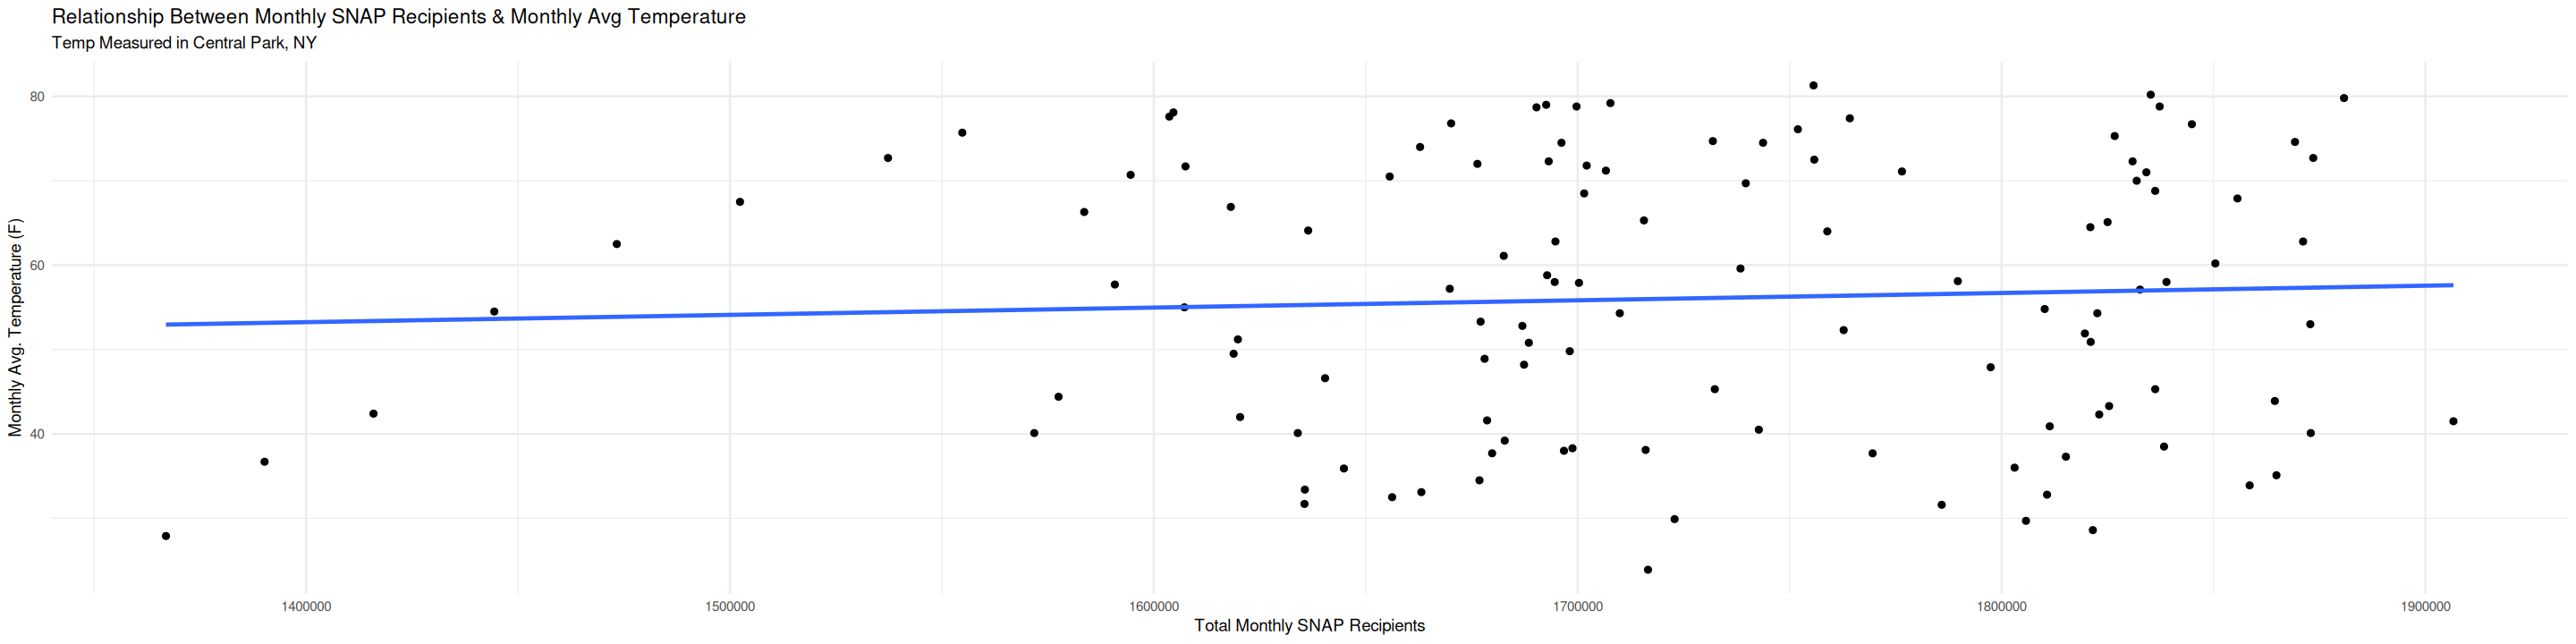

In [88]:
scatterplot <- ggplot(merged_snap_temp, aes(x = total_SNAP_recipients, y = temperatureF)) +
  geom_point() +
  geom_smooth(method = 'lm', se = FALSE) +
  labs(
    title = "Relationship Between Monthly SNAP Recipients & Monthly Avg Temperature",
    subtitle = "Temp Measured in Central Park, NY",
    x = "Total Monthly SNAP Recipients",
    y = "Monthly Avg. Temperature (F)"
  ) +
  theme_minimal()

scatterplot

# maybe look at number of extreme heat days per month with relation to monthly snap benefits
# define the methodology of how you quantified extreme heat days in nyc

In [89]:
# Read in daily temperatures from 1/1/2009-12/31/2009. This data is from the "Daily Data Listing" from the following database: https://scacis.rcc-acis.org/

# Read in daily temp CSV file
dailyT <- read.csv('SC_ACIS2_NYC_Central_Park_2009_2018.csv', header = TRUE)

# Explore the data file
dim(dailyT)
names(dailyT)
glimpse(dailyT)
summary(dailyT)
str(dailyT)
head(dailyT)
tail(dailyT)


[1] 3652    8

[1] "Station"        "Date"           "MaxTemperature" "MinTemperature"
[5] "Precipitation"  "Snowfall"       "SnowDepth"      "SourcePage"

Rows: 3,652
Columns: 8
$ Station        <chr> "NY CITY CENTRAL PARK, NY", "NY CITY CENTRAL PARK, NY",…
$ Date           <chr> "2009-01-01", "2009-01-02", "2009-01-03", "2009-01-04",…
$ MaxTemperature <int> 26, 34, 38, 42, 43, 38, 38, 38, 32, 30, 31, 33, 41, 36,…
$ MinTemperature <int> 15, 23, 29, 25, 38, 31, 31, 29, 26, 23, 24, 21, 28, 16,…
$ Precipitation  <chr> "0.00", "T", "T", "0.00", "T", "0.08", "1.19", "0.00", …
$ Snowfall       <chr> "0.0", "T", "T", "0.0", "0.0", "T", "0.0", "0.0", "0.0"…
$ SnowDepth      <chr> "0", "0", "0", "0", "0", "0", "0", "0", "0", "0", "1", …
$ SourcePage     <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…


   Station              Date           MaxTemperature  MinTemperature 
 Length:3652        Length:3652        Min.   : 13.0   Min.   :-1.00  
 Class :character   Class :character   1st Qu.: 48.0   1st Qu.:36.00  
 Mode  :character   Mode  :character   Median : 65.0   Median :50.00  
                                       Mean   : 63.2   Mean   :49.03  
                                       3rd Qu.: 79.0   3rd Qu.:64.00  
                                       Max.   :104.0   Max.   :84.00  
 Precipitation        Snowfall          SnowDepth           SourcePage   
 Length:3652        Length:3652        Length:3652        Min.   : 1.00  
 Class :character   Class :character   Class :character   1st Qu.:18.00  
 Mode  :character   Mode  :character   Mode  :character   Median :36.00  
                                                          Mean   :35.65  
                                                          3rd Qu.:53.00  
                                                          M

'data.frame':	3652 obs. of  8 variables:
 $ Station       : chr  "NY CITY CENTRAL PARK, NY" "NY CITY CENTRAL PARK, NY" "NY CITY CENTRAL PARK, NY" "NY CITY CENTRAL PARK, NY" ...
 $ Date          : chr  "2009-01-01" "2009-01-02" "2009-01-03" "2009-01-04" ...
 $ MaxTemperature: int  26 34 38 42 43 38 38 38 32 30 ...
 $ MinTemperature: int  15 23 29 25 38 31 31 29 26 23 ...
 $ Precipitation : chr  "0.00" "T" "T" "0.00" ...
 $ Snowfall      : chr  "0.0" "T" "T" "0.0" ...
 $ SnowDepth     : chr  "0" "0" "0" "0" ...
 $ SourcePage    : int  1 1 1 1 1 1 1 1 1 1 ...


,Station,Date,MaxTemperature,MinTemperature,Precipitation,Snowfall,SnowDepth,SourcePage
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>
1,"NY CITY CENTRAL PARK, NY",2009-01-01,26,15,0.00,0.0,0,1
2,"NY CITY CENTRAL PARK, NY",2009-01-02,34,23,T,T,0,1
3,"NY CITY CENTRAL PARK, NY",2009-01-03,38,29,T,T,0,1
4,"NY CITY CENTRAL PARK, NY",2009-01-04,42,25,0.00,0.0,0,1
5,"NY CITY CENTRAL PARK, NY",2009-01-05,43,38,T,0.0,0,1
6,"NY CITY CENTRAL PARK, NY",2009-01-06,38,31,0.08,T,0,1


,Station,Date,MaxTemperature,MinTemperature,Precipitation,Snowfall,SnowDepth,SourcePage
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>
3647,"NY CITY CENTRAL PARK, NY",2018-12-26,43,32,0.00,0.0,0,71
3648,"NY CITY CENTRAL PARK, NY",2018-12-27,44,37,0.00,0.0,0,71
3649,"NY CITY CENTRAL PARK, NY",2018-12-28,60,43,1.15,0.0,0,71
3650,"NY CITY CENTRAL PARK, NY",2018-12-29,57,39,0.00,0.0,0,71
3651,"NY CITY CENTRAL PARK, NY",2018-12-30,40,33,T,T,0,71
3652,"NY CITY CENTRAL PARK, NY",2018-12-31,48,36,1.02,0.0,0,71


In [90]:

# Get rid of irrelevant pieces of data: Station, Precipitation, Snowfall, SnowDepth, SourcePage
dailyT_clean <- dailyT %>%
    select(Date:MinTemperature)


head(dailyT_clean)
tail(dailyT_clean)

# convert date into date format
dailyT_clean <- dailyT_clean %>%
    mutate(Date = as.Date(dailyT_clean$Date, format = "%Y-%m-%d"))

head(dailyT_clean)
tail(dailyT_clean)

,Date,MaxTemperature,MinTemperature
,<chr>,<int>,<int>
1,2009-01-01,26,15
2,2009-01-02,34,23
3,2009-01-03,38,29
4,2009-01-04,42,25
5,2009-01-05,43,38
6,2009-01-06,38,31


,Date,MaxTemperature,MinTemperature
,<chr>,<int>,<int>
3647,2018-12-26,43,32
3648,2018-12-27,44,37
3649,2018-12-28,60,43
3650,2018-12-29,57,39
3651,2018-12-30,40,33
3652,2018-12-31,48,36


,Date,MaxTemperature,MinTemperature
,<date>,<int>,<int>
1,2009-01-01,26,15
2,2009-01-02,34,23
3,2009-01-03,38,29
4,2009-01-04,42,25
5,2009-01-05,43,38
6,2009-01-06,38,31


,Date,MaxTemperature,MinTemperature
,<date>,<int>,<int>
3647,2018-12-26,43,32
3648,2018-12-27,44,37
3649,2018-12-28,60,43
3650,2018-12-29,57,39
3651,2018-12-30,40,33
3652,2018-12-31,48,36


In [91]:
# save cleaned files
write.csv(dailyT_clean,
          "/home/user/capstone/irs_eds_capstone/data/processed_data/dailyT_clean_file.csv",
          row.names = FALSE)

write.csv(snap_data_clean,
          "/home/user/capstone/irs_eds_capstone/data/processed_data/snap_data_clean_file.csv", 
          row.names = FALSE)

[1] 63.1988

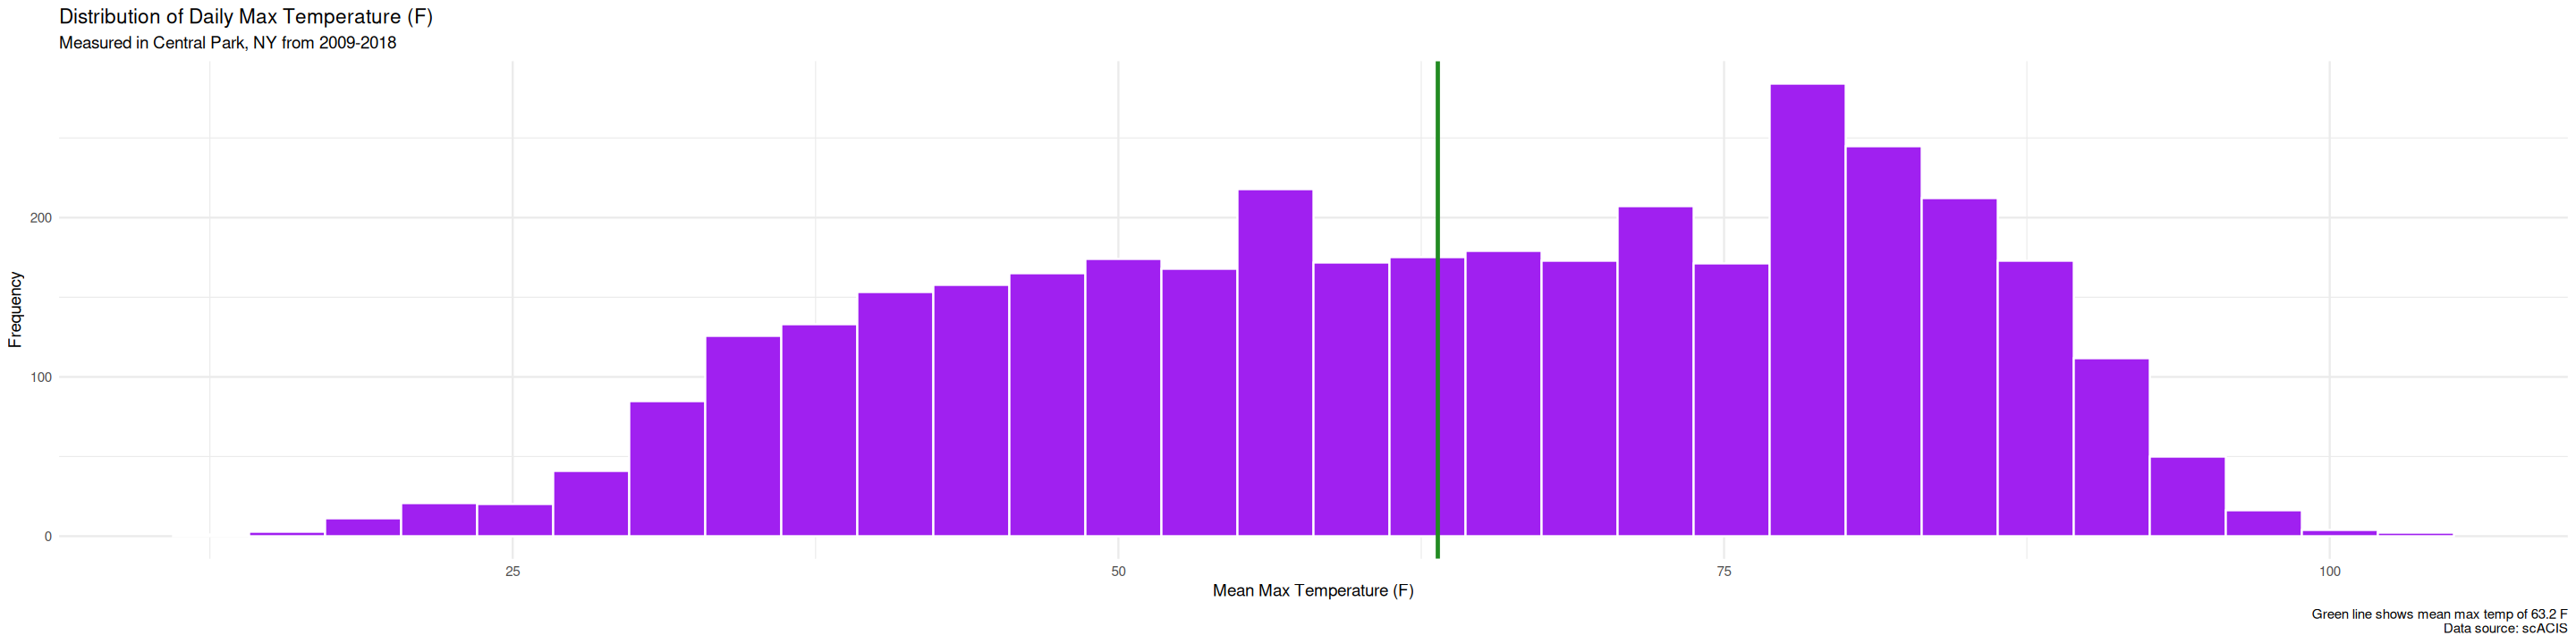

In [92]:
# Visualize the distribution of daily temperatures from 2009 to 2018. 

mean_max_temp <- mean(dailyT_clean$MaxTemperature, na.rm = TRUE)

mean_max_temp

dailyT_Dist <- ggplot(dailyT_clean, aes(x = MaxTemperature)) +
  geom_histogram(bins = 30, fill = 'purple', color = 'white') +
  geom_vline(xintercept = mean_max_temp, linewidth = 1, color = 'forestgreen')+
  labs(
    title = "Distribution of Daily Max Temperature (F)",
    subtitle = "Measured in Central Park, NY from 2009-2018",
    x = "Mean Max Temperature (F)",
    y = "Frequency",
    caption = "Green line shows mean max temp of 63.2 F\nData source: scACIS"
  ) +
  theme_minimal()

dailyT_Dist

ggsave("dailyT_Dist.png", 
       plot = dailyT_Dist,
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)

 Date[1:3652], format: "2009-01-01" "2009-01-02" "2009-01-03" "2009-01-04" "2009-01-05" ...


Rows: 3,652
Columns: 3
$ Date           <date> 2009-01-01, 2009-01-02, 2009-01-03, 2009-01-04, 2009-0…
$ MaxTemperature <int> 26, 34, 38, 42, 43, 38, 38, 38, 32, 30, 31, 33, 41, 36,…
$ MinTemperature <int> 15, 23, 29, 25, 38, 31, 31, 29, 26, 23, 24, 21, 28, 16,…


,Date,MaxTemperature,MinTemperature
,<date>,<int>,<int>
1,2009-01-01,26,15
2,2009-01-02,34,23
3,2009-01-03,38,29
4,2009-01-04,42,25
5,2009-01-05,43,38
6,2009-01-06,38,31


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


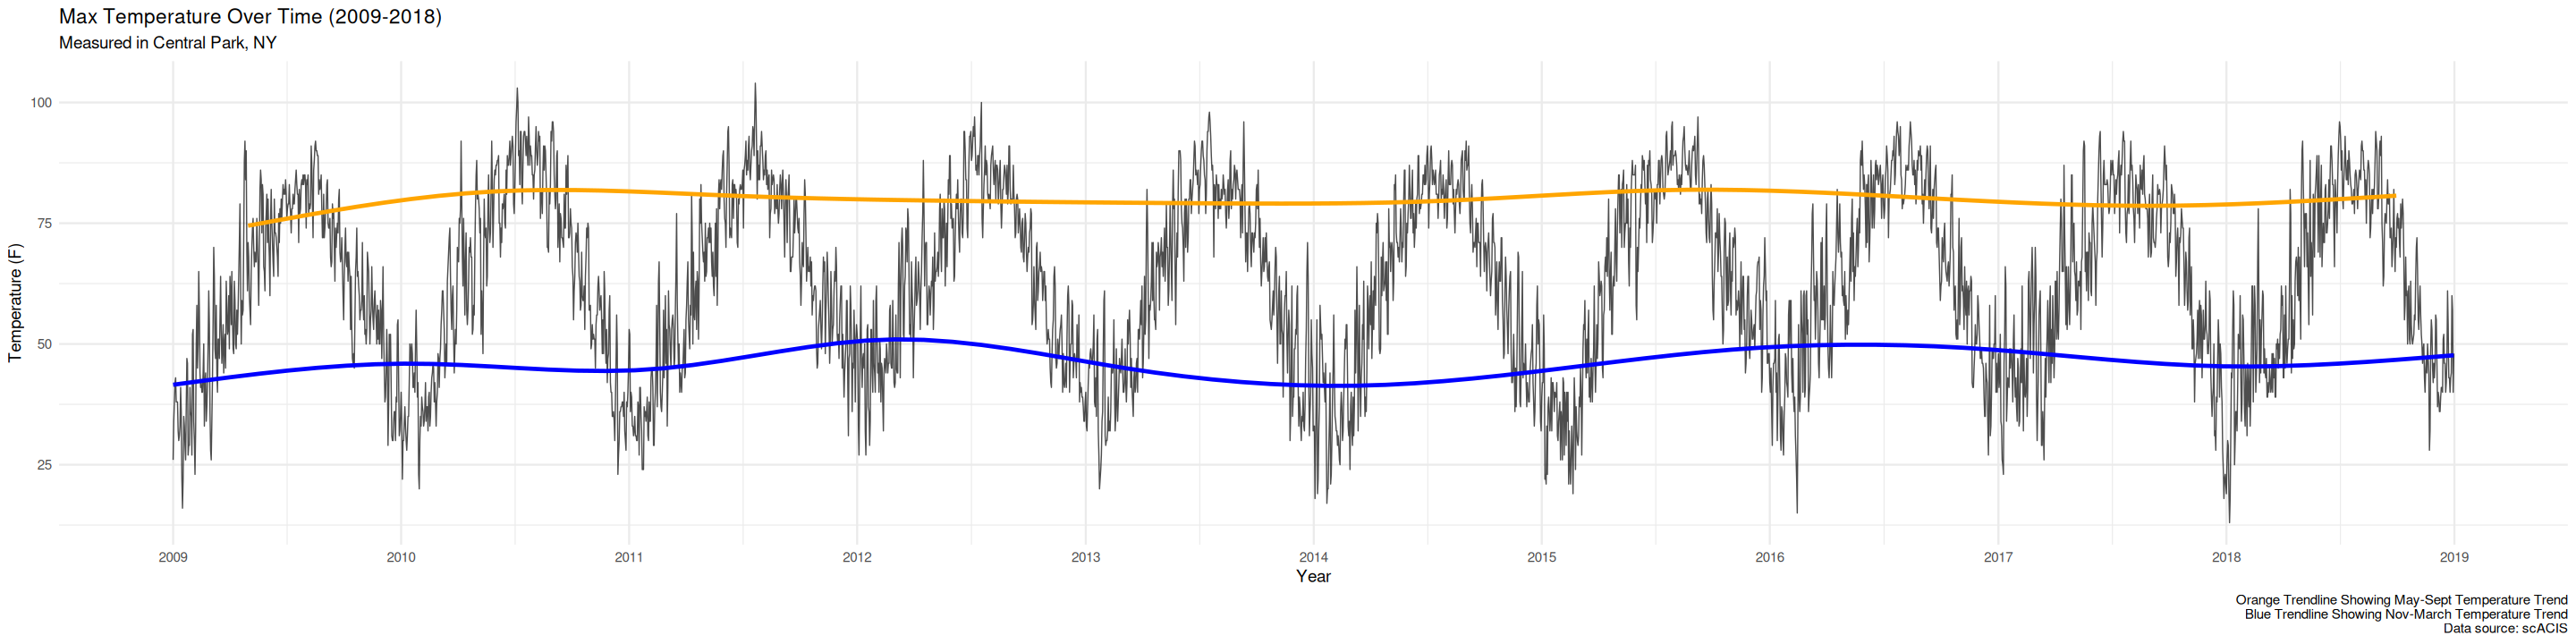

In [93]:
# Visualize Change Over Time

# Convert dates from characters into Dates
str(dailyT_clean$Date)
dailyT_clean$Date <- as.Date(dailyT_clean$Date)
glimpse(dailyT_clean)

head(dailyT_clean)

dailyT_timeseries <- ggplot(dailyT_clean, aes(x = Date, y = MaxTemperature)) +
    geom_line(linewidth = 0.3, alpha = 0.7) +
    geom_smooth(data = dailyT_clean %>% filter(month(Date) %in% 5:9), se = FALSE, linewidth = 1, color = 'orange') +
    geom_smooth(data = dailyT_clean %>% filter(month(Date) >= 11 | month(Date) <= 3), se = FALSE, linewidth = 1, color = 'blue') +
  labs(
    title = "Max Temperature Over Time (2009-2018)",
    subtitle = "Measured in Central Park, NY",
    x = "Year",
    y = "Temperature (F)",
    caption = 'Orange Trendline Showing May-Sept Temperature Trend\nBlue Trendline Showing Nov-March Temperature Trend\nData source: scACIS'
  ) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
  theme_minimal()

dailyT_timeseries

ggsave("dailyT_timeseries.png", 
       plot = dailyT_timeseries, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 16, height = 6, dpi = 300)

In [94]:
# Since we're looking at heat as it relates to food insecurity, let's isolate summer months in both datasets. We're working with May through September, defined in NYC's Heat-Related Mortality Report as the warm season. 

# Start by isolating May-Sept in SNAP dataset
glimpse(snap_data_clean)

# Need to convert date from character to proper date format first
snap_data_clean <- snap_data_clean %>%
    rename(month_chr = "month") %>%
    mutate(month_date = my(month_chr))

glimpse(snap_data_clean)

snap_data_clean <- snap_data_clean %>%
    select(month_date, total_SNAP_recipients)

glimpse(snap_data_clean)

snap_warm <- snap_data_clean %>%
      filter(month(month_date) %in% 5:9)

dim(snap_warm)
names(snap_warm)
glimpse(snap_warm)
summary(snap_warm)
str(snap_warm)
head(snap_warm)
tail(snap_warm)

# Arrange the data so it's oldest to newest, instead of newest to oldest. 
snap_warm <- snap_warm %>%
    arrange(month_date)

glimpse(snap_warm)

Rows: 120
Columns: 2
$ month                 <chr> "Dec 2018", "Nov 2018", "Oct 2018", "Sep 2018", …
$ total_SNAP_recipients <dbl> 1571790, 1577524, 1590812, 1594530, 1604622, 160…


Rows: 120
Columns: 3
$ month_chr             <chr> "Dec 2018", "Nov 2018", "Oct 2018", "Sep 2018", …
$ total_SNAP_recipients <dbl> 1571790, 1577524, 1590812, 1594530, 1604622, 160…
$ month_date            <date> 2018-12-01, 2018-11-01, 2018-10-01, 2018-09-01,…


Rows: 120
Columns: 2
$ month_date            <date> 2018-12-01, 2018-11-01, 2018-10-01, 2018-09-01,…
$ total_SNAP_recipients <dbl> 1571790, 1577524, 1590812, 1594530, 1604622, 160…


[1] 50  2

[1] "month_date"            "total_SNAP_recipients"

...

   month_date         total_SNAP_recipients
 Min.   :2009-05-01   Min.   :1473304      
 1st Qu.:2011-07-08   1st Qu.:1671692      
 Median :2013-12-31   Median :1711674      
 Mean   :2013-12-30   Mean   :1723589      
 3rd Qu.:2016-06-23   3rd Qu.:1826271      
 Max.   :2018-09-01   Max.   :1880790      

'data.frame':	50 obs. of  2 variables:
 $ month_date           : Date, format: "2018-09-01" "2018-08-01" ...
 $ total_SNAP_recipients: num  1594530 1604622 1603658 1607466 1618164 ...


,month_date,total_SNAP_recipients
,<date>,<dbl>
1,2018-09-01,1594530
2,2018-08-01,1604622
3,2018-07-01,1603658
4,2018-06-01,1607466
5,2018-05-01,1618164
6,2017-09-01,1655650


,month_date,total_SNAP_recipients
,<date>,<dbl>
45,2010-05-01,1715629
46,2009-09-01,1583581
47,2009-08-01,1554815
48,2009-07-01,1537284
49,2009-06-01,1502368
50,2009-05-01,1473304


Rows: 50
Columns: 2
$ month_date            <date> 2009-05-01, 2009-06-01, 2009-07-01, 2009-08-01,…
$ total_SNAP_recipients <dbl> 1473304, 1502368, 1537284, 1554815, 1583581, 171…


In [95]:
# Next, isolate May-Sept in daily temp dataset
glimpse(dailyT_clean)

dailyT_warm <- dailyT_clean %>% filter(month(Date) %in% 5:9)

dim(dailyT_warm)
names(dailyT_warm)
glimpse(dailyT_warm)
summary(dailyT_warm)
str(dailyT_warm)
head(dailyT_warm)
tail(dailyT_warm)

Rows: 3,652
Columns: 3
$ Date           <date> 2009-01-01, 2009-01-02, 2009-01-03, 2009-01-04, 2009-0…
$ MaxTemperature <int> 26, 34, 38, 42, 43, 38, 38, 38, 32, 30, 31, 33, 41, 36,…
$ MinTemperature <int> 15, 23, 29, 25, 38, 31, 31, 29, 26, 23, 24, 21, 28, 16,…


[1] 1530    3

[1] "Date"           "MaxTemperature" "MinTemperature"

Rows: 1,530
Columns: 3
$ Date           <date> 2009-05-01, 2009-05-02, 2009-05-03, 2009-05-04, 2009-0…
$ MaxTemperature <int> 71, 68, 60, 57, 54, 65, 70, 74, 76, 70, 66, 69, 67, 67,…
$ MinTemperature <int> 53, 54, 52, 51, 51, 49, 51, 56, 58, 54, 50, 50, 49, 56,…


      Date            MaxTemperature  MinTemperature 
 Min.   :2009-05-01   Min.   : 48.0   Min.   :41.00  
 1st Qu.:2011-07-16   1st Qu.: 74.0   1st Qu.:59.00  
 Median :2014-01-14   Median : 81.0   Median :66.00  
 Mean   :2014-01-14   Mean   : 79.8   Mean   :64.53  
 3rd Qu.:2016-07-15   3rd Qu.: 86.0   3rd Qu.:70.00  
 Max.   :2018-09-30   Max.   :104.0   Max.   :84.00  

'data.frame':	1530 obs. of  3 variables:
 $ Date          : Date, format: "2009-05-01" "2009-05-02" ...
 $ MaxTemperature: int  71 68 60 57 54 65 70 74 76 70 ...
 $ MinTemperature: int  53 54 52 51 51 49 51 56 58 54 ...


,Date,MaxTemperature,MinTemperature
,<date>,<int>,<int>
1,2009-05-01,71,53
2,2009-05-02,68,54
3,2009-05-03,60,52
4,2009-05-04,57,51
5,2009-05-05,54,51
6,2009-05-06,65,49


,Date,MaxTemperature,MinTemperature
,<date>,<int>,<int>
1525,2018-09-25,73,59
1526,2018-09-26,82,69
1527,2018-09-27,72,61
1528,2018-09-28,65,56
1529,2018-09-29,72,58
1530,2018-09-30,70,54


In [96]:
# Now we want to figure out how many extreme heat days there are per month. We will use two different parameters: 82F are non extreme heat days, of which there have been more as time has gone on, and 95F, which is the extreme heat threshold, as defined by the 2025 NYC Heat-Related Mortality Report
# https://a816-dohbesp.nyc.gov/IndicatorPublic/data-features/heat-report/

# Start by figuring out how many days in each month are over 95F. 
monthly_heat95 <- dailyT_warm %>%
    group_by(month_date = floor_date(Date, "month")) %>%
    mutate(over_95 = if_else(MaxTemperature > 95, 1, 0)) %>%
    summarize(
        heat_days_95F = sum(over_95, na.rm = TRUE),
        .groups = "drop"
    )

monthly_heat95


# Figure out how many days in each month are over 82F. 
monthly_heat82 <- dailyT_warm %>%
    group_by(month_date = floor_date(Date, "month")) %>%
    mutate(over_82 = if_else(MaxTemperature > 82, 1, 0)) %>%
    summarize(
        heat_days_82F = sum(over_82, na.rm = TRUE),
        .groups = "drop"
    )

monthly_heat82

month_date,heat_days_95F
<date>,<dbl>
2009-05-01,0
2009-06-01,0
2009-07-01,0
2009-08-01,0
2009-09-01,0
2010-05-01,0
2010-06-01,0
2010-07-01,5
2010-08-01,1


month_date,heat_days_82F
<date>,<dbl>
2009-05-01,3
2009-06-01,2
2009-07-01,11
2009-08-01,17
2009-09-01,2
2010-05-01,7
2010-06-01,17
2010-07-01,28
2010-08-01,20


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


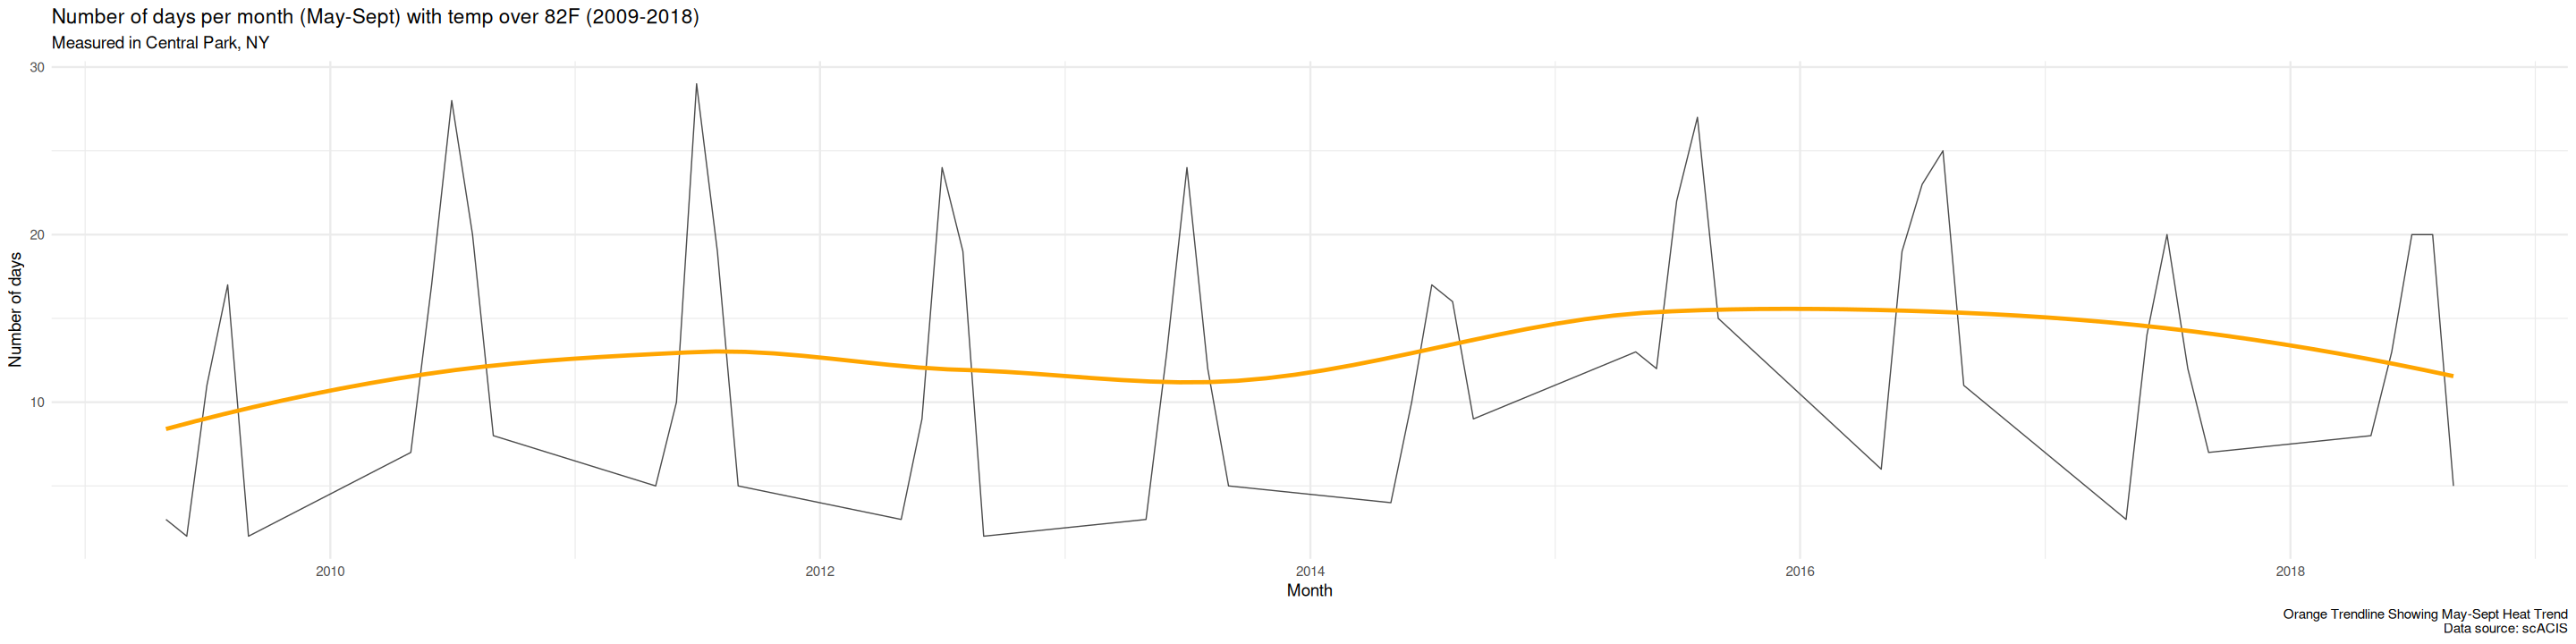

In [97]:
# Make a time series for months with days >82F because the data for >95F days is so limited. 

monthly_heat82_timeseries <- ggplot(monthly_heat82, aes(x = month_date, y = heat_days_82F)) +
    geom_line(linewidth = 0.3, alpha = 0.7) +
    geom_smooth(se = FALSE, linewidth = 1, color = 'orange') +
#     scale_x_date(
#       date_breaks = "1 month",
#       date_labels = "%b"
#     )+
    labs(
        title = "Number of days per month (May-Sept) with temp over 82F (2009-2018)",
        subtitle = "Measured in Central Park, NY",
        x = "Month",
        y = "Number of days",
        caption = 'Orange Trendline Showing May-Sept Heat Trend\nData source: scACIS'
    ) +
    theme_minimal()

monthly_heat82_timeseries


ggsave("monthly_heat82_timeseries.png", 
       plot = monthly_heat82_timeseries, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 16, height = 6, dpi = 300)



In [98]:

# Arrange full snap data so it's oldest to newest, instead of newest to oldest. 
snap_data_clean <- snap_data_clean %>%
    arrange(month_date)

head(snap_data_clean)



# Figure out how many days in each month are over 82F for all months of the year, instead of just May-Sept. 
monthly_over82 <- dailyT_clean %>%
    group_by(month_date = floor_date(Date, "month")) %>%
    mutate(over_82 = if_else(MaxTemperature > 82, 1, 0)) %>%
    summarize(
        heat_days_82F = sum(over_82, na.rm = TRUE),
        .groups = "drop"
    )


monthly_over82

,month_date,total_SNAP_recipients
,<date>,<dbl>
1,2009-01-01,1366942
2,2009-02-01,1390204
3,2009-03-01,1415907
4,2009-04-01,1444403
5,2009-05-01,1473304
6,2009-06-01,1502368


month_date,heat_days_82F
<date>,<dbl>
2009-01-01,0
2009-02-01,0
2009-03-01,0
2009-04-01,4
2009-05-01,3
2009-06-01,2
2009-07-01,11
2009-08-01,17
2009-09-01,2


In [99]:

# combine snap monthly and temp monthly days 82F data sets. 

# start by checking to see that both datasets have the same length. 
dim(snap_data_clean)
dim(monthly_over82)


# merge the two datasets
snap_temp82 <- snap_data_clean %>%
    left_join(monthly_over82, by = 'month_date')

head(snap_temp82)

[1] 120   2

[1] 120   2

,month_date,total_SNAP_recipients,heat_days_82F
,<date>,<dbl>,<dbl>
1,2009-01-01,1366942,0
2,2009-02-01,1390204,0
3,2009-03-01,1415907,0
4,2009-04-01,1444403,4
5,2009-05-01,1473304,3
6,2009-06-01,1502368,2


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


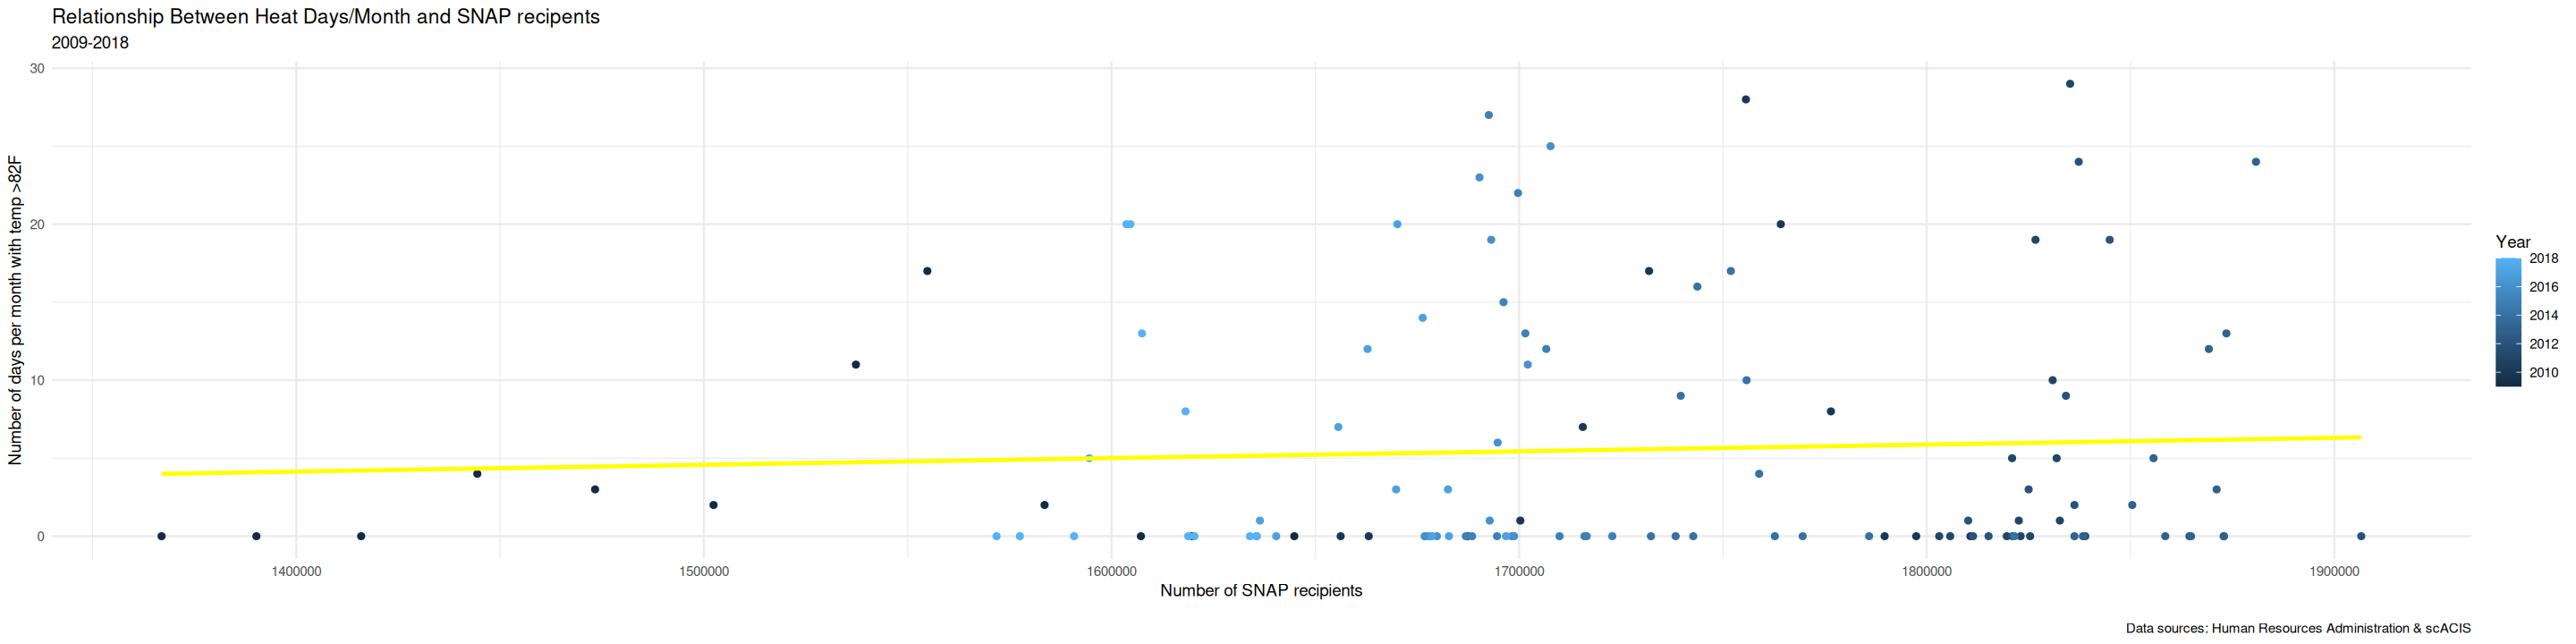

In [101]:
# Now let's try checking a scatterplot! This includes the full years of data from 2009-2018.

snap_temp82 <- snap_temp82 %>%
  mutate(Year = year(month_date))

snap_temp82_scatter <- ggplot(snap_temp82, aes(x = total_SNAP_recipients, y = heat_days_82F, color = Year)) +
  geom_point() +
  geom_smooth(method = 'lm', color = 'yellow', se = FALSE) +
  labs(
    title = "Relationship Between Heat Days/Month and SNAP recipents",
    subtitle = "2009-2018",
    x = "Number of SNAP recipients",
    y = "Number of days per month with temp >82F",
    caption = "\nData sources: Human Resources Administration & scACIS"
  ) +
  theme_minimal()

snap_temp82_scatter

ggsave("snap_temp82_scatter.png", 
       plot = snap_temp82_scatter, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


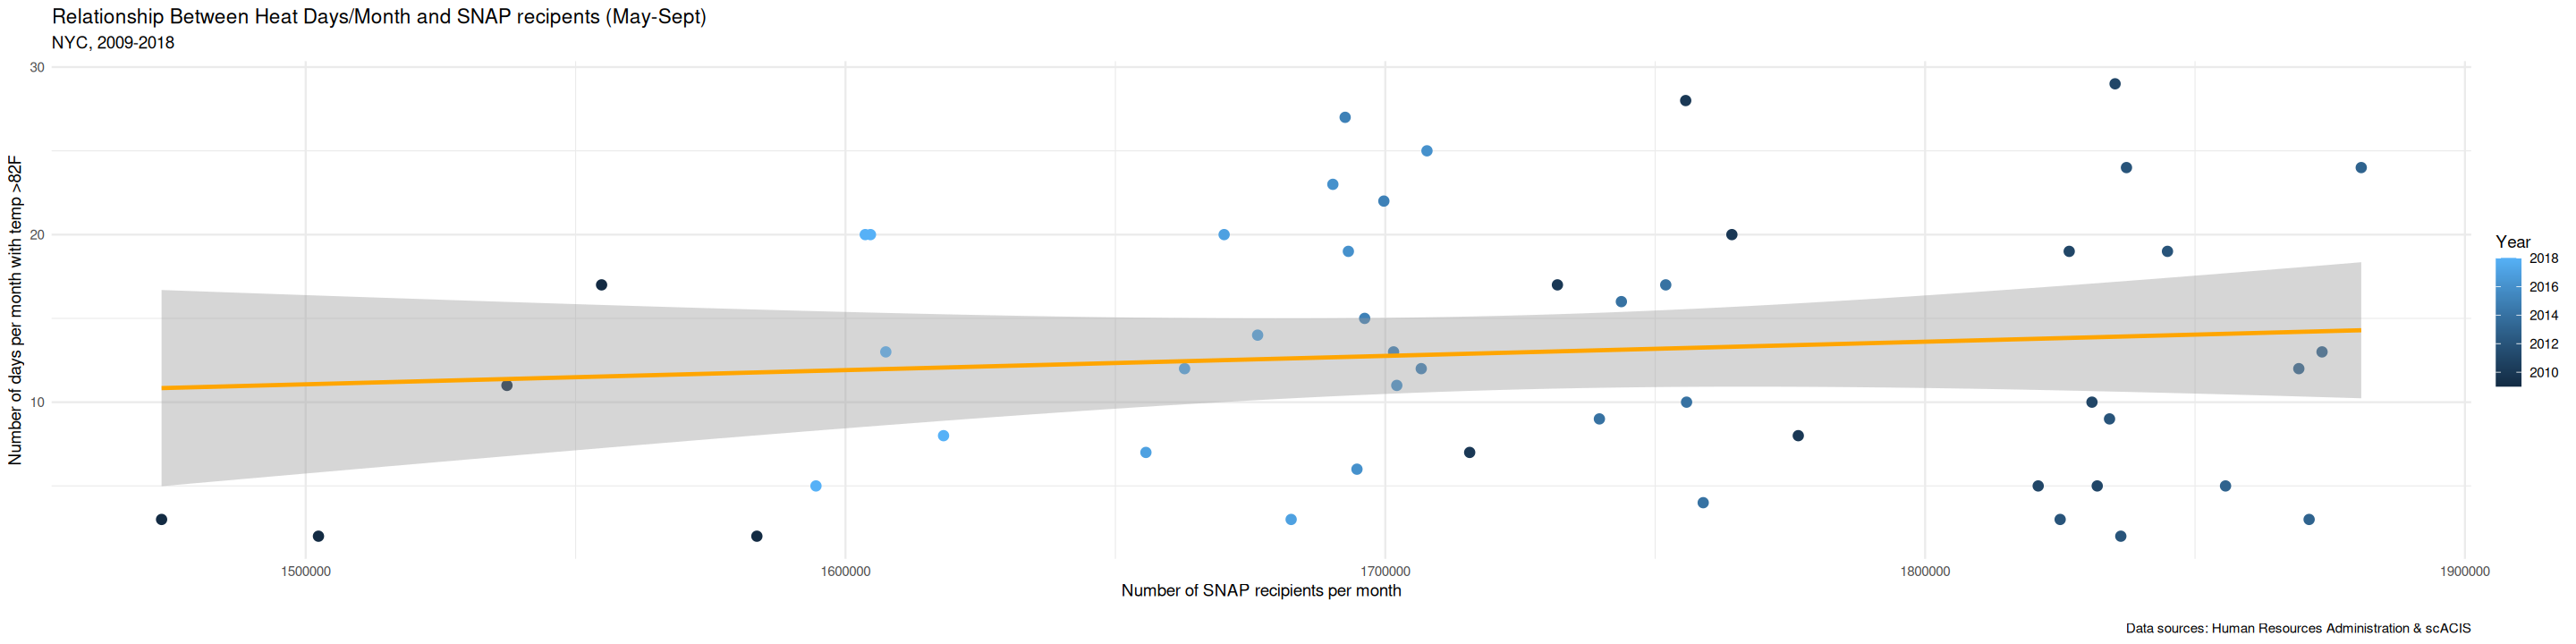

In [102]:
# Now try making the scatterplot for only the warm months: May-Sept

snap_temp82_warm <- snap_temp82 %>%
    filter(month(month_date) %in% 5:9)

snap_temp82_warm_scatter <- ggplot(snap_temp82_warm, aes(x = total_SNAP_recipients, y = heat_days_82F, color = Year)) +
  geom_point(size = 2.5) +
  geom_smooth(method = 'lm', color = 'orange', se = TRUE) +
  labs(
    title = "Relationship Between Heat Days/Month and SNAP recipents (May-Sept)",
    subtitle = "NYC, 2009-2018",
    x = "Number of SNAP recipients per month",
    y = "Number of days per month with temp >82F",
    caption = "\nData sources: Human Resources Administration & scACIS"
  ) +
  theme_minimal()

snap_temp82_warm_scatter

ggsave("snap_temp82_warm_scatter.png", 
       plot = snap_temp82_warm_scatter, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)


In [103]:
# In preparation to run our regressions, make a lagged temperature variable. This lets us see the number of days the month prior that had temp >82F. 
snap_temp82_warm <- snap_temp82_warm %>%
  arrange(month_date) %>%
  mutate(
    heat_lag1 = lag(heat_days_82F, 1)
  )

head(snap_temp82_warm)

,month_date,total_SNAP_recipients,heat_days_82F,Year,heat_lag1,Month
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,2009-05-01,1473304,3,2009,NA,5
2,2009-06-01,1502368,2,2009,3,6
3,2009-07-01,1537284,11,2009,2,7
4,2009-08-01,1554815,17,2009,11,8
5,2009-09-01,1583581,2,2009,17,9
6,2010-05-01,1715629,7,2010,2,5


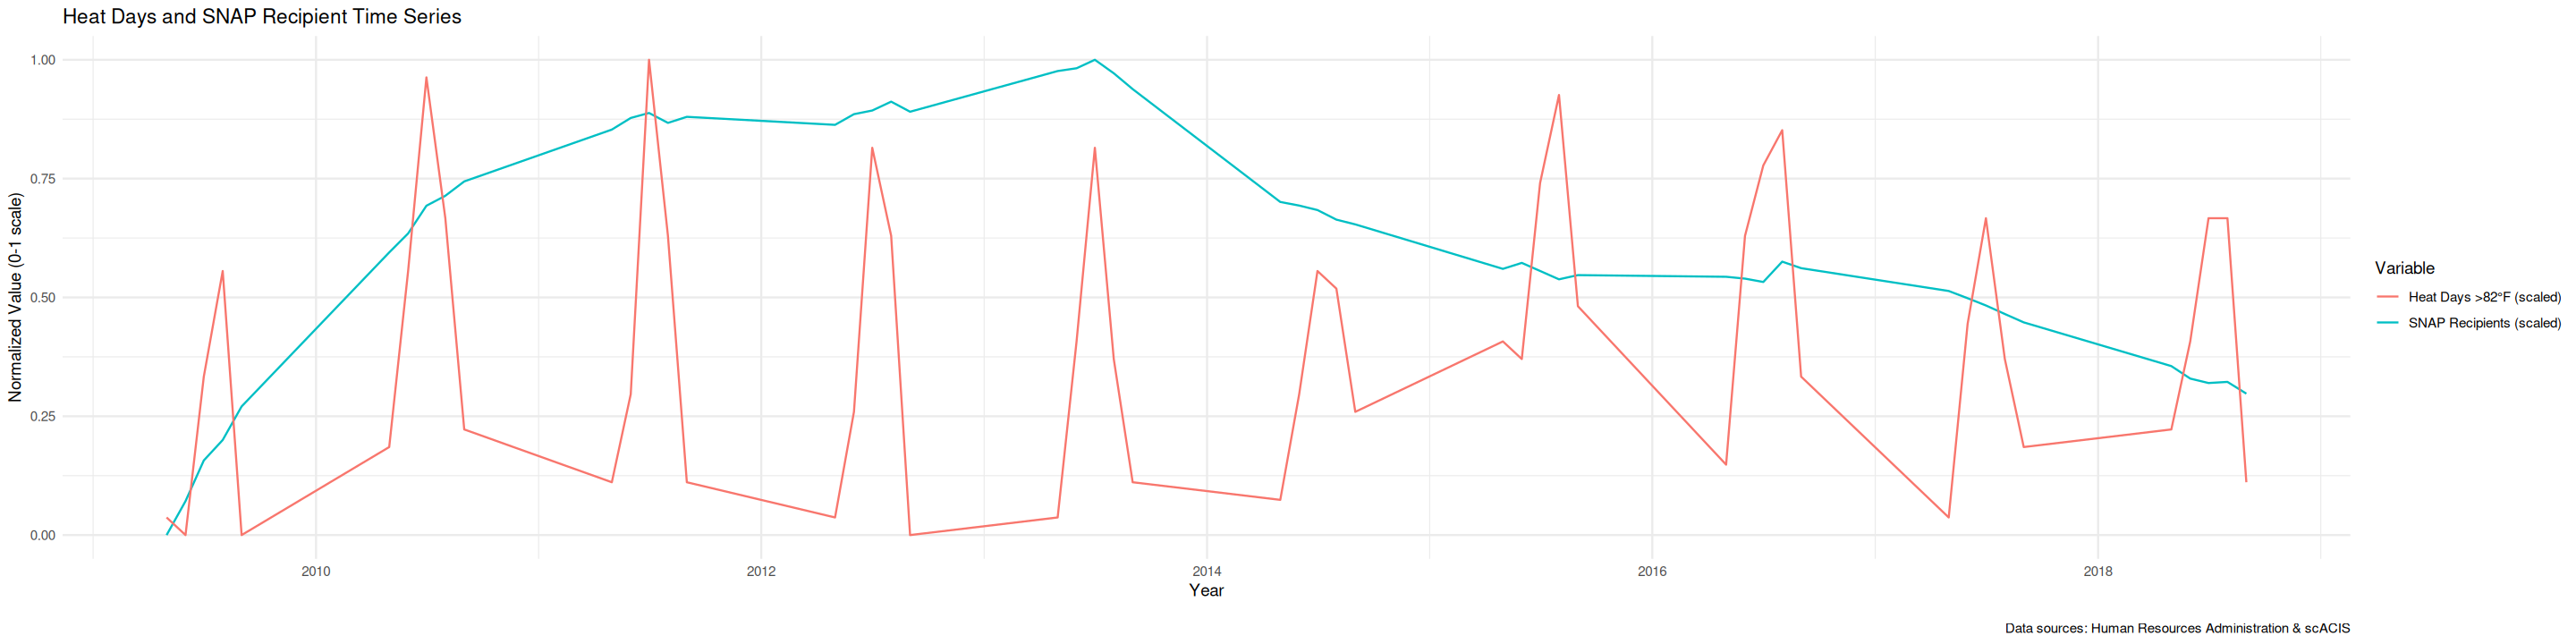

In [105]:
# Now let's visualize both monthly SNAP recipients and monthly number of days >82F on a timeseries plot together

# First, scale both variables so they fit on one chart. This step normalizes both variables on a 0 to 1 scale so they can be compared over time. 

# scale everything
head(snap_temp82_warm)
snap_temp_scaled <- snap_temp82_warm %>%
  mutate(
    snap_scaled = (snap_temp82_warm$total_SNAP_recipients - min(snap_temp82_warm$total_SNAP_recipients)) / 
      (max(snap_temp82_warm$total_SNAP_recipients) - min(snap_temp82_warm$total_SNAP_recipients)),
    heat_scaled = (snap_temp82_warm$heat_days_82F - min(snap_temp82_warm$heat_days_82F)) /
      (max(snap_temp82_warm$heat_days_82F) - min(snap_temp82_warm$heat_days_82F)),
    heat_lag1_scaled = (heat_lag1 - min(heat_lag1, na.rm = TRUE)) /
      (max(heat_lag1, na.rm = TRUE) - min(heat_lag1, na.rm = TRUE)),
    Month = factor(month(month_date))
      )

# Make a factor variable for month to control for seasonality
snap_temp82_warm <- snap_temp82_warm %>%
  mutate(
    Month = factor(month(month_date)),
  )

# Next, plot the timeseries 
snap_temp_timeseries <- ggplot(snap_temp_scaled, aes(x = month_date)) +
  geom_line(aes(y = snap_scaled, color = "SNAP Recipients (scaled)")) +
  geom_line(aes(y = heat_scaled, color = "Heat Days >82°F (scaled)")) +
  labs(
      title = 'Heat Days and SNAP Recipient Time Series',
      x = "Year",
      y = "Normalized Value (0-1 scale)",
      color = "Variable",
      caption = "\nData sources: Human Resources Administration & scACIS"

  ) +
  theme_minimal()


snap_temp_timeseries

ggsave("snap_temp_timeseries.png", 
       plot = snap_temp_timeseries, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 14, height = 6, dpi = 300)

Warning message:
“Use of `snap_temp82_warm$total_SNAP_recipients` is discouraged.
ℹ Use `total_SNAP_recipients` instead.”


Warning message:
“Use of `snap_temp82_warm$heat_days_82F` is discouraged.
ℹ Use `heat_days_82F` instead.”


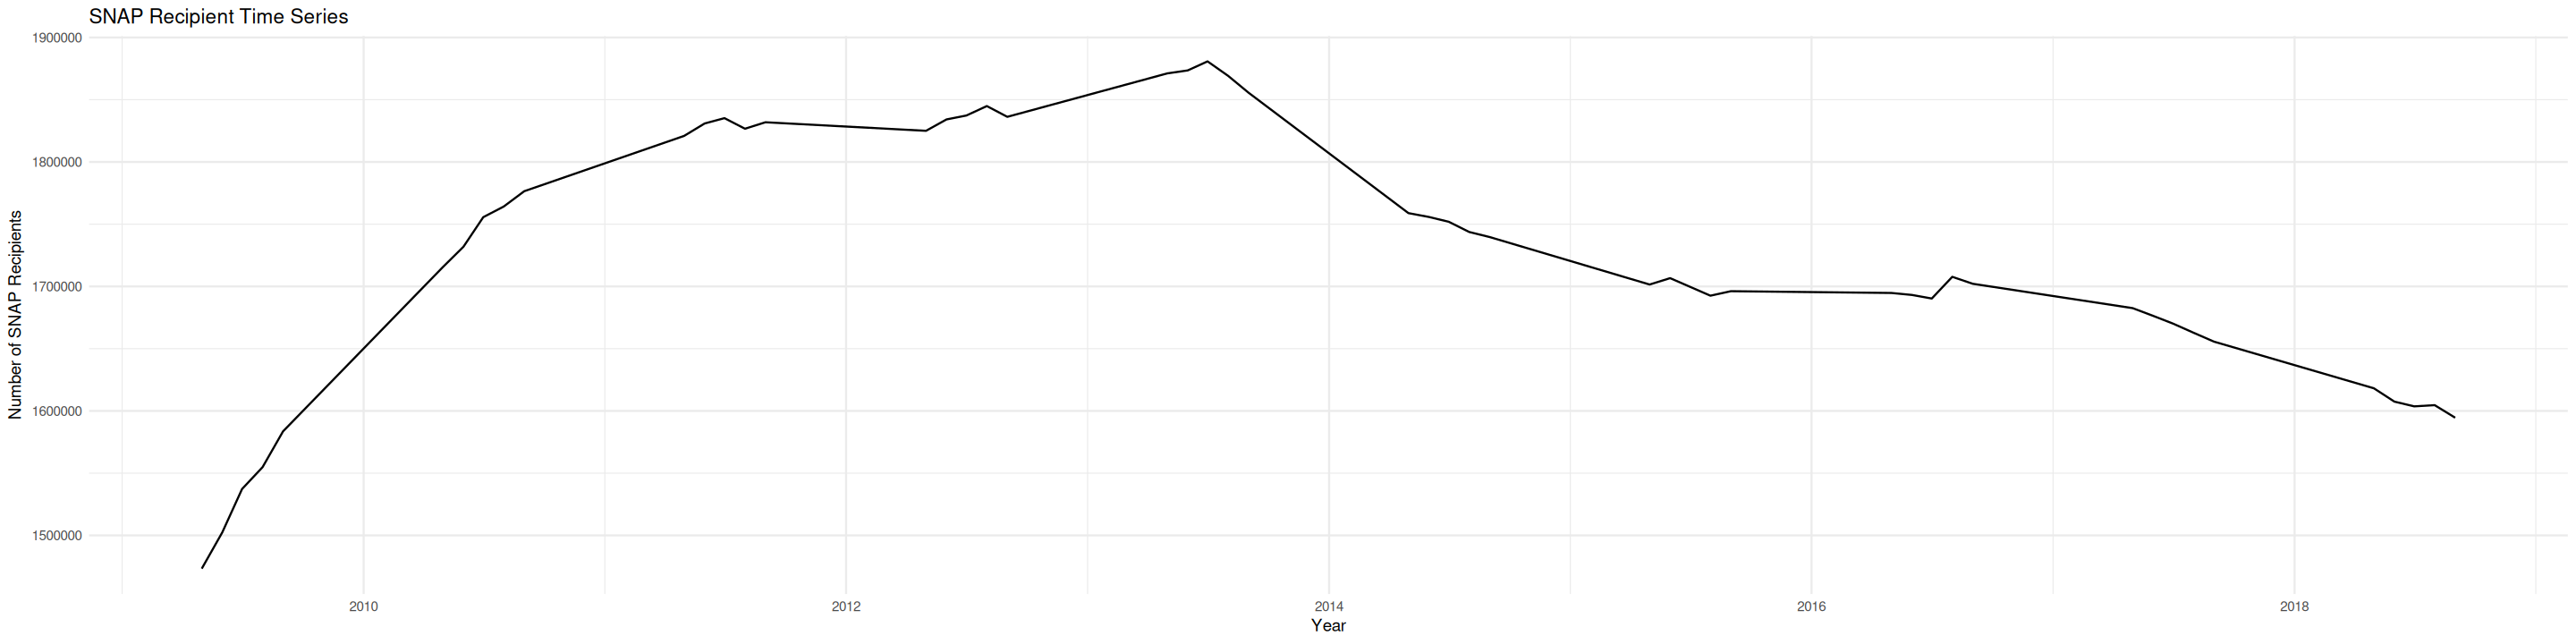

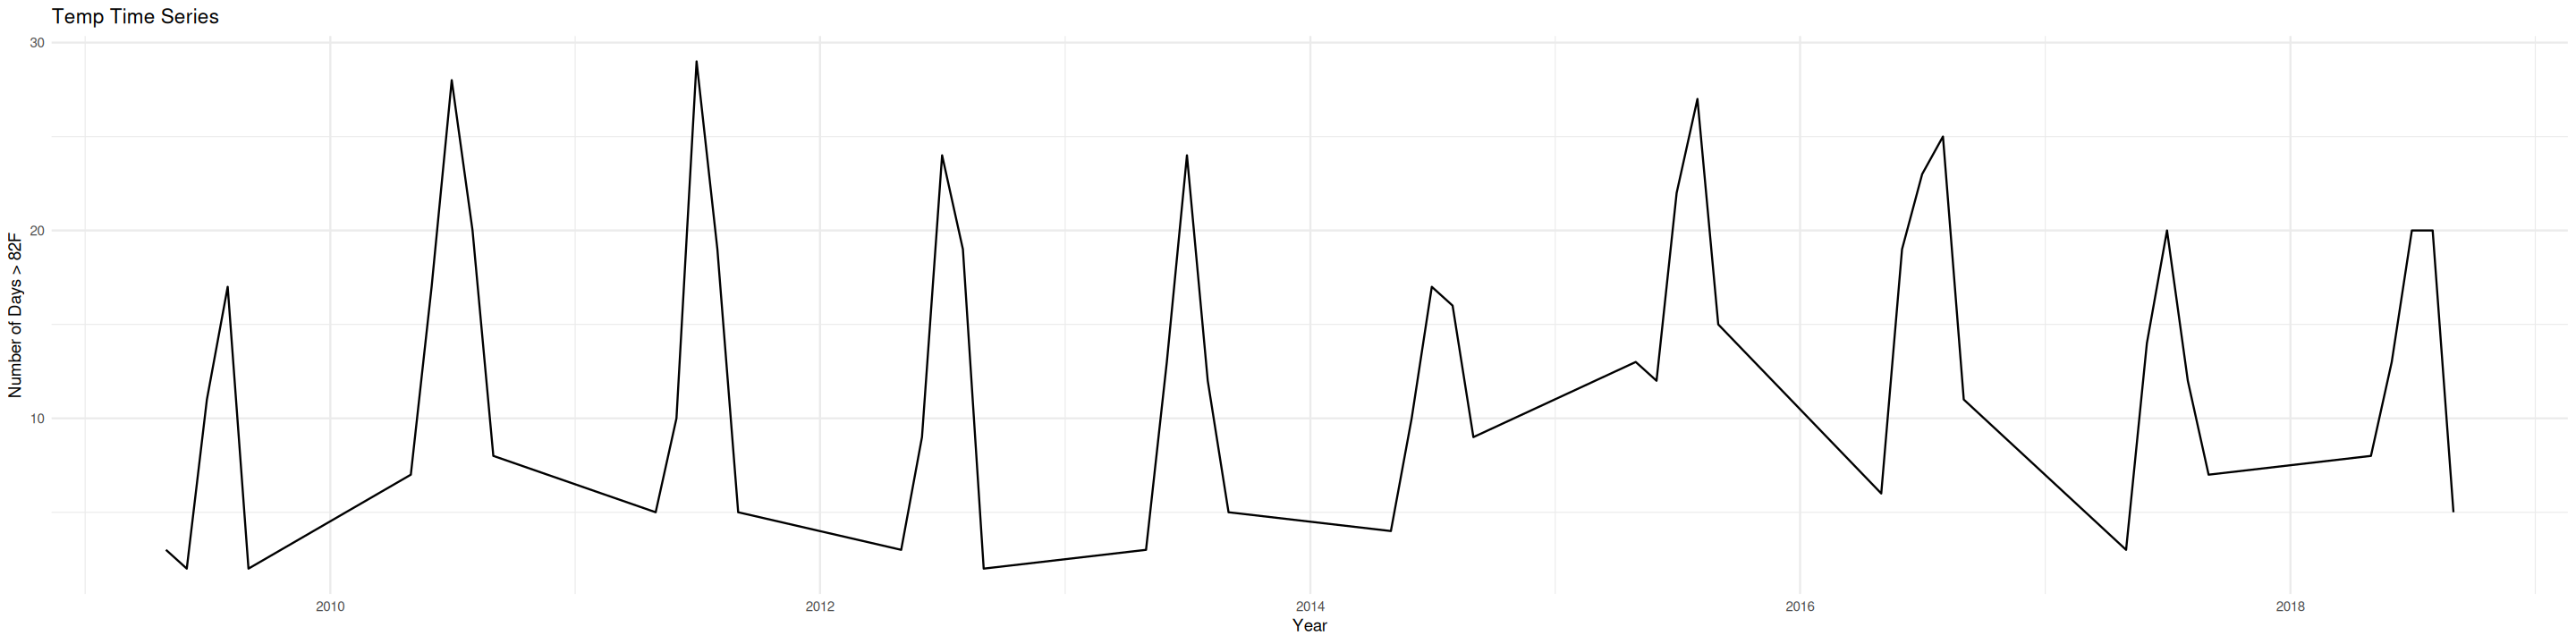

In [106]:
# Let's make  individual time series for each unscaled variable just to see how they compare visually to the combined timeseries made above. This will help verify that the scaling worked. 

snap_timeseries <- ggplot(snap_temp82_warm, aes(x = month_date, y=snap_temp82_warm$total_SNAP_recipients)) +
  geom_line() +
  labs(
      title = 'SNAP Recipient Time Series',
      x = "Year",
      y = "Number of SNAP Recipients",
  ) +
  theme_minimal()


snap_timeseries


temp_timeseries <- ggplot(snap_temp82_warm, aes(x = month_date, y=snap_temp82_warm$heat_days_82F)) +
  geom_line() +
  labs(
      title = 'Temp Time Series',
      x = "Year",
      y = "Number of Days > 82F",
  ) +
  theme_minimal()


temp_timeseries

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


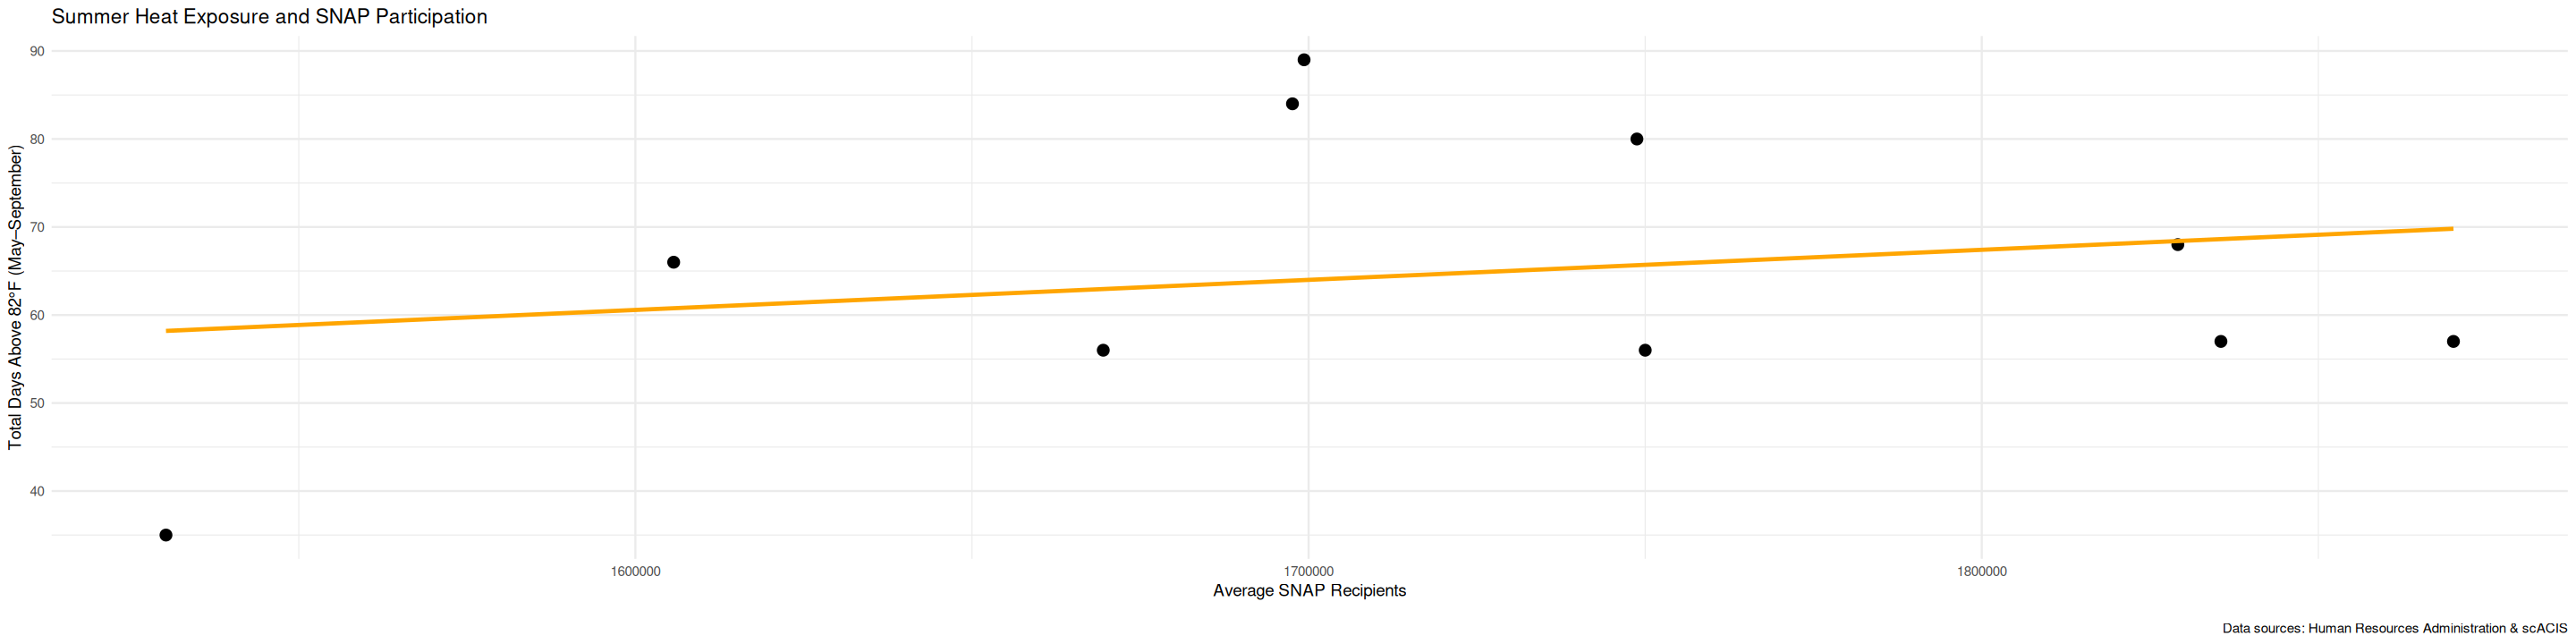

In [107]:
# Let's try to make a plot now that agreggates by year, rather than by month. This means we're checking the relationship between annual snap participants and annual days with temp >92F (just for the months of May-June)

annual_snap_temp_warm <- snap_temp82_warm %>%
    mutate(Year = year(month_date)) %>%
    group_by(Year) %>%
    summarize(
        total_heat_days = sum(heat_days_82F),
        avg_snap = mean(total_SNAP_recipients),
        .groups = "drop"
    )


annual_snap_temp_warm_scatter <- ggplot(annual_snap_temp_warm,
       aes(x = avg_snap, y = total_heat_days)) +
    geom_point(size = 3) +
    geom_smooth(method = "lm", se = FALSE, color = "orange") +
    labs(
        title = "Summer Heat Exposure and SNAP Participation",
        x = "Average SNAP Recipients",
        y = "Total Days Above 82°F (May–September)",
        caption = "\nData sources: Human Resources Administration & scACIS"

    ) +
    theme_minimal()

annual_snap_temp_warm_scatter

ggsave("annual_snap_temp_warm_scatter.png", 
       plot = annual_snap_temp_warm_scatter, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)

In [109]:
# Let's run some correlations: 

# correlation between monthly snap recipients and total heat days per month (May-Sept)
cor(snap_temp82_warm$heat_days_82F,
    snap_temp82_warm$total_SNAP_recipients)

# correlation between total heat days annually and average snap recipients annually (May-Sept)
cor(annual_snap_temp_warm$total_heat_days,
    annual_snap_temp_warm$avg_snap)


# Let's try the monthy snap and heat days correlation with the scaled values. 
cor(snap_temp_scaled$heat_scaled,
   snap_temp_scaled$snap_scaled)

# Let's try a correlation between monthly snap recipients (scaled) and lagged heat (scaled)
cor(snap_temp_scaled$heat_lag1_scaled,
   snap_temp_scaled$snap_scaled,
    use = "complete.obs")

[1] 0.1128045

[1] 0.2244315

[1] 0.1128045

[1] 0.05069192

In [110]:
head(snap_temp_scaled)

# Let's run some regressions. Start by running the regression with the totoal monthly snap recipients and total days per month over 82F, for May through September:
lm1 <- lm(total_SNAP_recipients ~ heat_days_82F,
          data = snap_temp_scaled)

summary(lm1)

,month_date,total_SNAP_recipients,heat_days_82F,Year,heat_lag1,Month,snap_scaled,heat_scaled,heat_lag1_scaled
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
1,2009-05-01,1473304,3,2009,NA,5,0.00000000,0.03703704,NA
2,2009-06-01,1502368,2,2009,3,6,0.07132515,0.00000000,0.03703704
3,2009-07-01,1537284,11,2009,2,7,0.15701153,0.33333333,0.00000000
4,2009-08-01,1554815,17,2009,11,8,0.20003387,0.55555556,0.33333333
5,2009-09-01,1583581,2,2009,17,9,0.27062770,0.00000000,0.55555556
6,2010-05-01,1715629,7,2010,2,5,0.59468301,0.18518519,0.00000000



Call:
lm(formula = total_SNAP_recipients ~ heat_days_82F, data = snap_temp_scaled)

Residuals:
    Min      1Q  Median      3Q     Max 
-235326  -57269   -7249   96354  162505 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    1704124      28757  59.260   <2e-16 ***
heat_days_82F     1502       1910   0.787    0.435    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 103600 on 48 degrees of freedom
Multiple R-squared:  0.01272,	Adjusted R-squared:  -0.007843 
F-statistic: 0.6187 on 1 and 48 DF,  p-value: 0.4354


In [111]:
# Now run a regression for the current and lagged temperature effects. Here, you'll look at the relationship between total snap recipients each month and the number of hot days in that same month, as well as the relationship between total snap recipients each month and the number of hot days in the month prior. 

# Run the  multi-linear regression

lm2 <- lm(total_SNAP_recipients ~ heat_days_82F +
                                    heat_lag1 +
                                    Month +
                                    Year,
          data = snap_temp_scaled)

summary(lm2)


Call:
lm(formula = total_SNAP_recipients ~ heat_days_82F + heat_lag1 + 
    Month + Year, data = snap_temp_scaled)

Residuals:
    Min      1Q  Median      3Q     Max 
-228205  -57663   -8880   56767  155372 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)   26785444   10361701   2.585   0.0134 *
heat_days_82F     3932       3578   1.099   0.2782  
heat_lag1         3111       3606   0.863   0.3932  
Month6          -47241      51175  -0.923   0.3613  
Month7         -101115      70337  -1.438   0.1581  
Month8         -118796      72812  -1.632   0.1104  
Month9          -62676      60774  -1.031   0.3084  
Year            -12456       5149  -2.419   0.0201 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 97310 on 41 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.1516,	Adjusted R-squared:  0.006698 
F-statistic: 1.046 on 7 and 41 DF,  p-value: 0.4148


In [112]:
# Now run both regressions over with the scaled variables. This step normalizes both variables on a 0 to 1 scale so they can be compared over time. The R squared values should remain the same as the two regressions above if it's done correctly.

# First, do contemporraneous - heat this month with snap this month
lm3 <- lm(snap_scaled ~ heat_scaled,
          data = snap_temp_scaled)

summary(lm3)



# Next, take into account lagged heat effects (the impact of heat last month on SNAP recipients this month)
lm4 <- lm(snap_scaled ~ heat_scaled +
                                    heat_lag1_scaled +
                                    Month +
                                    Year,
          data = snap_temp_scaled)

summary(lm4)




Call:
lm(formula = snap_scaled ~ heat_scaled, data = snap_temp_scaled)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.57751 -0.14054 -0.01779  0.23646  0.39880 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.57382    0.06269   9.154 4.22e-12 ***
heat_scaled  0.09952    0.12652   0.787    0.435    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2542 on 48 degrees of freedom
Multiple R-squared:  0.01272,	Adjusted R-squared:  -0.007843 
F-statistic: 0.6187 on 1 and 48 DF,  p-value: 0.4354



Call:
lm(formula = snap_scaled ~ heat_scaled + heat_lag1_scaled + Month + 
    Year, data = snap_temp_scaled)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.56003 -0.14151 -0.02179  0.13931  0.38129 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)  
(Intercept)      62.15239   25.43410   2.444   0.0189 *
heat_scaled       0.26056    0.23707   1.099   0.2782  
heat_lag1_scaled  0.20616    0.23892   0.863   0.3932  
Month6           -0.11593    0.12559  -0.923   0.3613  
Month7           -0.24814    0.17261  -1.438   0.1581  
Month8           -0.29153    0.17869  -1.632   0.1104  
Month9           -0.15381    0.14914  -1.031   0.3084  
Year             -0.03057    0.01264  -2.419   0.0201 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2388 on 41 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.1516,	Adjusted R-squared:  0.006698 
F-statistic: 1.046 on 7 and 41 DF,  

`geom_smooth()` using formula = 'y ~ x'


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


`geom_smooth()` using formula = 'y ~ x'


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


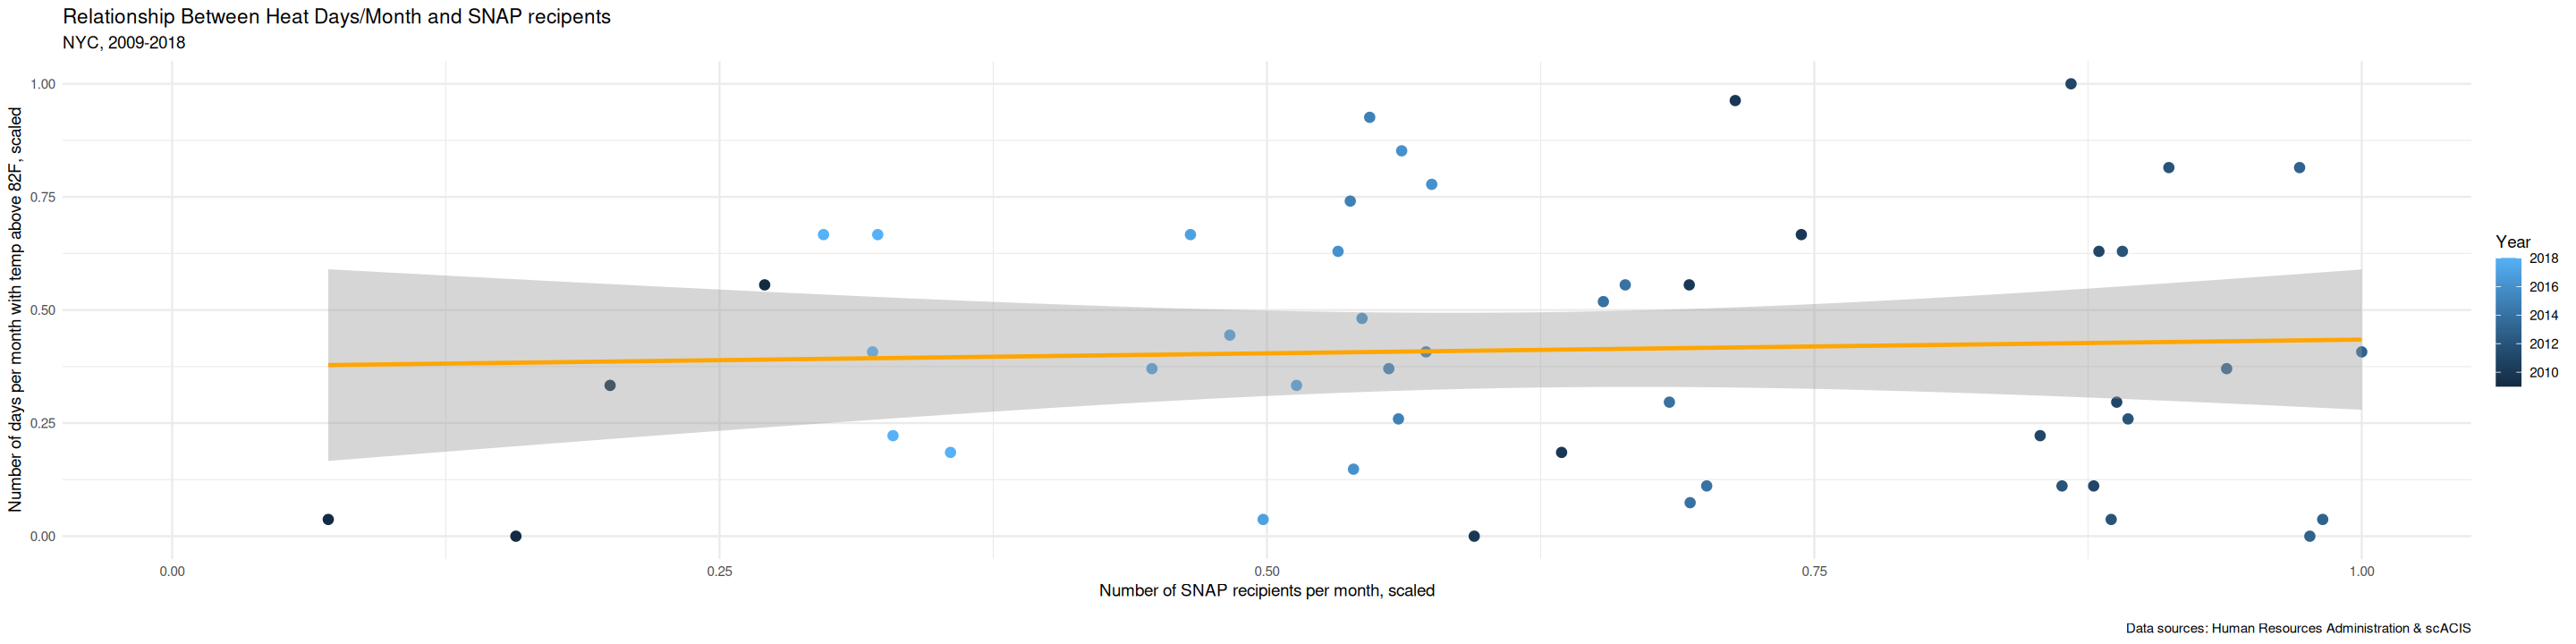

In [39]:
snap_temp82_warm_scatter3 <- ggplot(snap_temp_scaled, aes(x = snap_scaled, y = heat_lag1_scaled, color = Year)) +
  geom_point(size = 2.5) +
  geom_smooth(method = 'lm', color = 'orange', se = TRUE) +
  labs(
    title = "Relationship Between Heat Days/Month and SNAP recipents",
    subtitle = "NYC, 2009-2018",
    x = "Number of SNAP recipients per month, scaled",
    y = "Number of days per month with temp above 82F, scaled",
    caption = "\nData sources: Human Resources Administration & scACIS"
  ) +
  theme_minimal()

snap_temp82_warm_scatter3

ggsave("snap_temp82_warm_scatter3.png", 
       plot = snap_temp82_warm_scatter3, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)


In [113]:
#see all your regressions in one place

lm1 <- lm(total_SNAP_recipients ~ heat_days_82F,
          data = snap_temp_scaled)

summary(lm1)



lm2 <- lm(total_SNAP_recipients ~ heat_days_82F +
                                    heat_lag1 +
                                    Month +
                                    Year,
          data = snap_temp_scaled)

summary(lm2)



lm3 <- lm(snap_scaled ~ heat_scaled,
          data = snap_temp_scaled)

summary(lm3)



lm4 <- lm(snap_scaled ~ heat_scaled +
                                    heat_lag1_scaled +
                                    Month +
                                    Year,
          data = snap_temp_scaled)

summary(lm4)


Call:
lm(formula = total_SNAP_recipients ~ heat_days_82F, data = snap_temp_scaled)

Residuals:
    Min      1Q  Median      3Q     Max 
-235326  -57269   -7249   96354  162505 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    1704124      28757  59.260   <2e-16 ***
heat_days_82F     1502       1910   0.787    0.435    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 103600 on 48 degrees of freedom
Multiple R-squared:  0.01272,	Adjusted R-squared:  -0.007843 
F-statistic: 0.6187 on 1 and 48 DF,  p-value: 0.4354



Call:
lm(formula = total_SNAP_recipients ~ heat_days_82F + heat_lag1 + 
    Month + Year, data = snap_temp_scaled)

Residuals:
    Min      1Q  Median      3Q     Max 
-228205  -57663   -8880   56767  155372 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)   26785444   10361701   2.585   0.0134 *
heat_days_82F     3932       3578   1.099   0.2782  
heat_lag1         3111       3606   0.863   0.3932  
Month6          -47241      51175  -0.923   0.3613  
Month7         -101115      70337  -1.438   0.1581  
Month8         -118796      72812  -1.632   0.1104  
Month9          -62676      60774  -1.031   0.3084  
Year            -12456       5149  -2.419   0.0201 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 97310 on 41 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.1516,	Adjusted R-squared:  0.006698 
F-statistic: 1.046 on 7 and 41 DF,  p-value: 0.4148



Call:
lm(formula = snap_scaled ~ heat_scaled, data = snap_temp_scaled)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.57751 -0.14054 -0.01779  0.23646  0.39880 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.57382    0.06269   9.154 4.22e-12 ***
heat_scaled  0.09952    0.12652   0.787    0.435    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2542 on 48 degrees of freedom
Multiple R-squared:  0.01272,	Adjusted R-squared:  -0.007843 
F-statistic: 0.6187 on 1 and 48 DF,  p-value: 0.4354



Call:
lm(formula = snap_scaled ~ heat_scaled + heat_lag1_scaled + Month + 
    Year, data = snap_temp_scaled)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.56003 -0.14151 -0.02179  0.13931  0.38129 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)  
(Intercept)      62.15239   25.43410   2.444   0.0189 *
heat_scaled       0.26056    0.23707   1.099   0.2782  
heat_lag1_scaled  0.20616    0.23892   0.863   0.3932  
Month6           -0.11593    0.12559  -0.923   0.3613  
Month7           -0.24814    0.17261  -1.438   0.1581  
Month8           -0.29153    0.17869  -1.632   0.1104  
Month9           -0.15381    0.14914  -1.031   0.3084  
Year             -0.03057    0.01264  -2.419   0.0201 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2388 on 41 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.1516,	Adjusted R-squared:  0.006698 
F-statistic: 1.046 on 7 and 41 DF,  

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


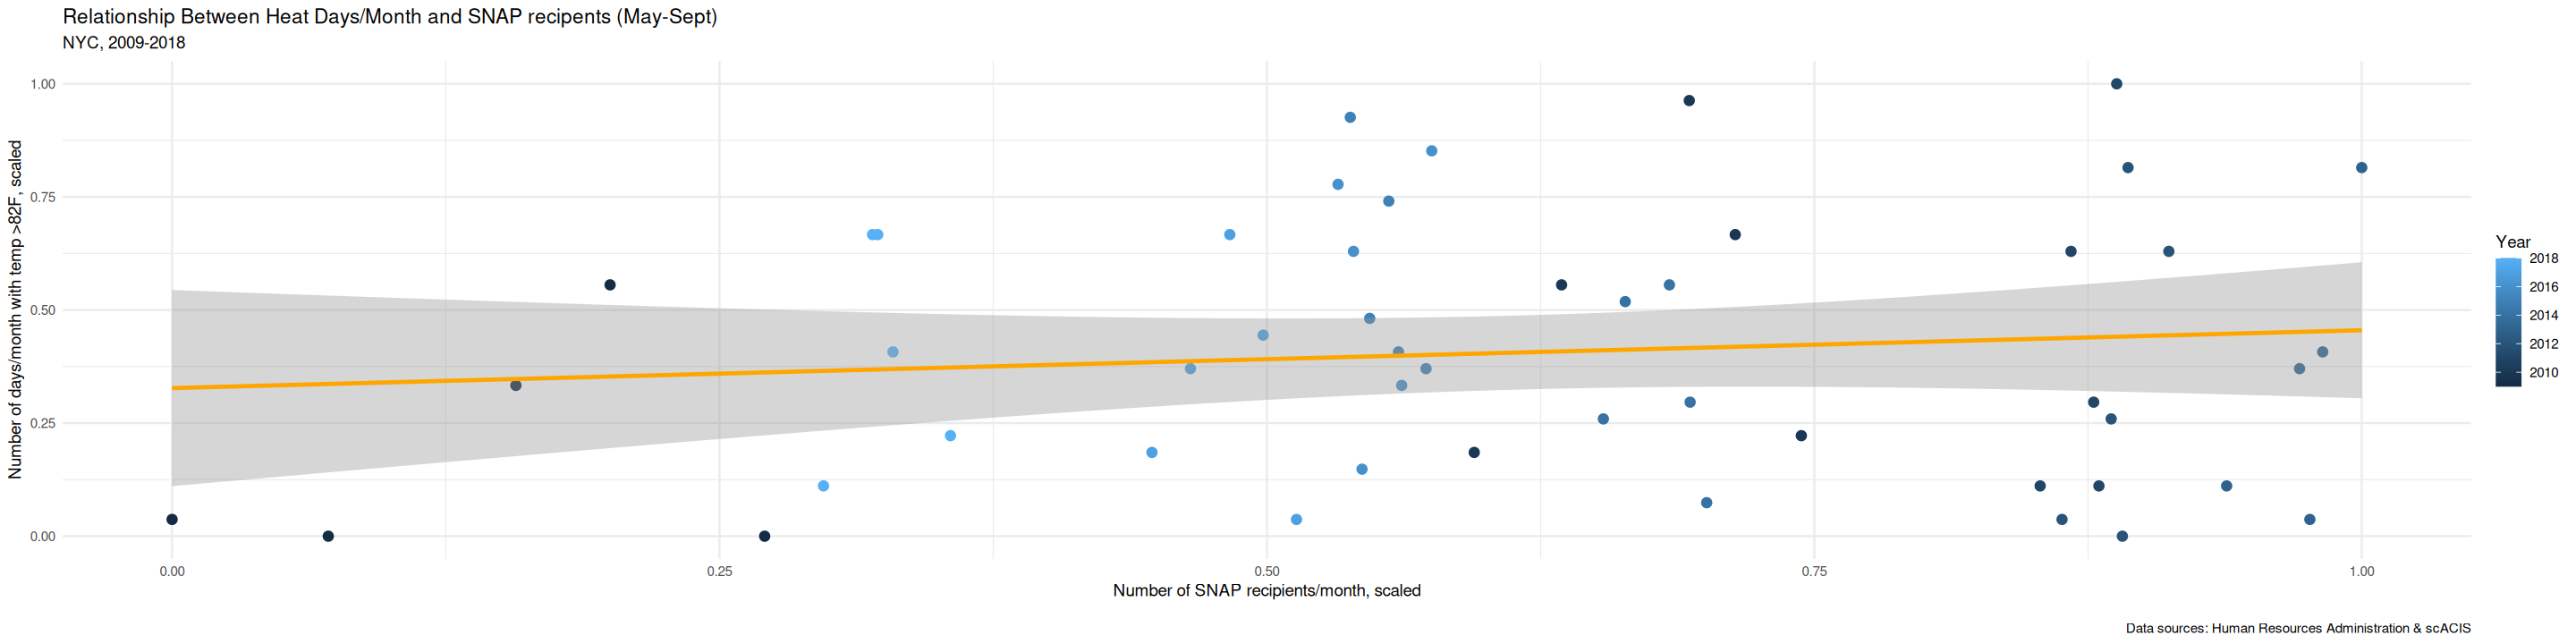

`geom_smooth()` using formula = 'y ~ x'


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


In [114]:
# Plot your two key scatterplots that correspond with the two scaled regressions.

# First, plot relationship between your scaled # of days with temp >82F (May-Sept) varialbe and scaled SNAP recipients (May-Sept) variable

snap_temp82_warm_scatter4 <- ggplot(snap_temp_scaled, aes(x = snap_scaled, y = heat_scaled, color = Year)) +
  geom_point(size = 2.5) +
  geom_smooth(method = 'lm', color = 'orange', se = TRUE) +
  labs(
    title = "Relationship Between Heat Days/Month and SNAP recipents (May-Sept)",
    subtitle = "NYC, 2009-2018",
    x = "Number of SNAP recipients/month, scaled",
    y = "Number of days/month with temp >82F, scaled",
    caption = "\nData sources: Human Resources Administration & scACIS"
  ) +
  theme_minimal()

snap_temp82_warm_scatter4

ggsave("snap_temp82_warm_scatter4.png", 
       plot = snap_temp82_warm_scatter4, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)


# Next, plot the relationship between lagged heat (# of days last month with temp >82F) and number of snap recipients in the current month

snap_temp82_warm_scatter5 <- ggplot(snap_temp_scaled, aes(x = snap_scaled, y = heat_lag1_scaled, color = Year)) +
  geom_point(size = 2.5) +
  geom_smooth(method = 'lm', color = 'yellow', se = TRUE) +
  labs(
    title = "Relationship Between Heat Days/Month (lagged) and SNAP recipents",
    subtitle = "NYC, 2009-2018",
    x = "Number of SNAP recipients/month, scaled",
    y = "Number of days/prior month with temp above 82F, scaled",
    caption = "\nData sources: Human Resources Administration & scACIS"
  ) +
  theme_minimal()

snap_temp82_warm_scatter5

ggsave("snap_temp82_warm_scatter5.png", 
       plot = snap_temp82_warm_scatter5, 
       path = '/home/user/capstone/irs_eds_capstone/data/outputs',
       width = 8, height = 6, dpi = 300)
